WEEK1

In [1]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
# loading the dataset
df = pd.read_csv('waterQuality_dataset.csv', sep=';')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,06.10.2020,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,27.10.2020,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,03.12.2020,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,12.01.2021,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [3]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2861 non-null   int64  
 1   date       2861 non-null   object 
 2   NH4        2858 non-null   float64
 3   BSK5       2860 non-null   float64
 4   Suspended  2845 non-null   float64
 5   O2         2858 non-null   float64
 6   NO3        2860 non-null   float64
 7   NO2        2858 non-null   float64
 8   SO4        2812 non-null   float64
 9   PO4        2833 non-null   float64
 10  CL         2812 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 246.0+ KB


In [4]:
df.head(5)

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [5]:
df.shape

(2861, 11)

In [6]:
# data statistics
df.describe()

,id,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
count,2861.000000,2858.000000,2860.000000,2845.000000,2858.000000,2860.000000,2858.000000,2812.000000,2833.000000,2812.000000
mean,12.397064,0.758734,4.316182,12.931905,9.508902,4.316846,0.246128,59.362313,0.418626,93.731991
std,6.084226,2.486247,2.973997,16.543097,4.428260,6.881188,2.182777,96.582641,0.771326,394.512184
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000
25%,8.000000,0.080000,2.160000,6.000000,7.092500,1.390000,0.030000,27.052500,0.130000,26.800000
50%,14.000000,0.220000,3.800000,10.000000,8.995000,2.800000,0.059000,37.800000,0.270000,33.900000
75%,16.000000,0.500000,5.800000,15.000000,11.520000,5.582500,0.125750,64.640000,0.470000,45.607500
max,22.000000,39.427000,50.900000,595.000000,90.000000,133.400000,109.000000,3573.400000,13.879000,5615.280000


In [7]:
# checking for null values
df.isnull().sum()

id            0
date          0
NH4           3
BSK5          1
Suspended    16
O2            3
NO3           1
NO2           3
SO4          49
PO4          28
CL           49
dtype: int64

In [8]:
# total number of null values
df.isnull().sum().sum()

153

In [9]:
# date is an object
# converting it to date format
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         2861 non-null   int64         
 1   date       2861 non-null   datetime64[ns]
 2   NH4        2858 non-null   float64       
 3   BSK5       2860 non-null   float64       
 4   Suspended  2845 non-null   float64       
 5   O2         2858 non-null   float64       
 6   NO3        2860 non-null   float64       
 7   NO2        2858 non-null   float64       
 8   SO4        2812 non-null   float64       
 9   PO4        2833 non-null   float64       
 10  CL         2812 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 246.0 KB


In [11]:
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [12]:
# checking for duplicates
df.duplicated().sum()

0

In [13]:
# sorting by id and date
df = df.sort_values(by=['id', 'date'])
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [14]:
# extracting year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [15]:
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5,2000,2
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0,2000,5
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0,2000,9
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0,2000,12
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0,2001,3


In [16]:
df.columns

Index(['id', 'date', 'NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL', 'year', 'month'],
      dtype='object')

In [17]:
station_ids = df['id'].unique()
station_ids

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22], dtype=int64)

In [18]:
# plotting components over time for each station
components = ['NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']

In [19]:
n_stations = len(station_ids)
n_stations

22

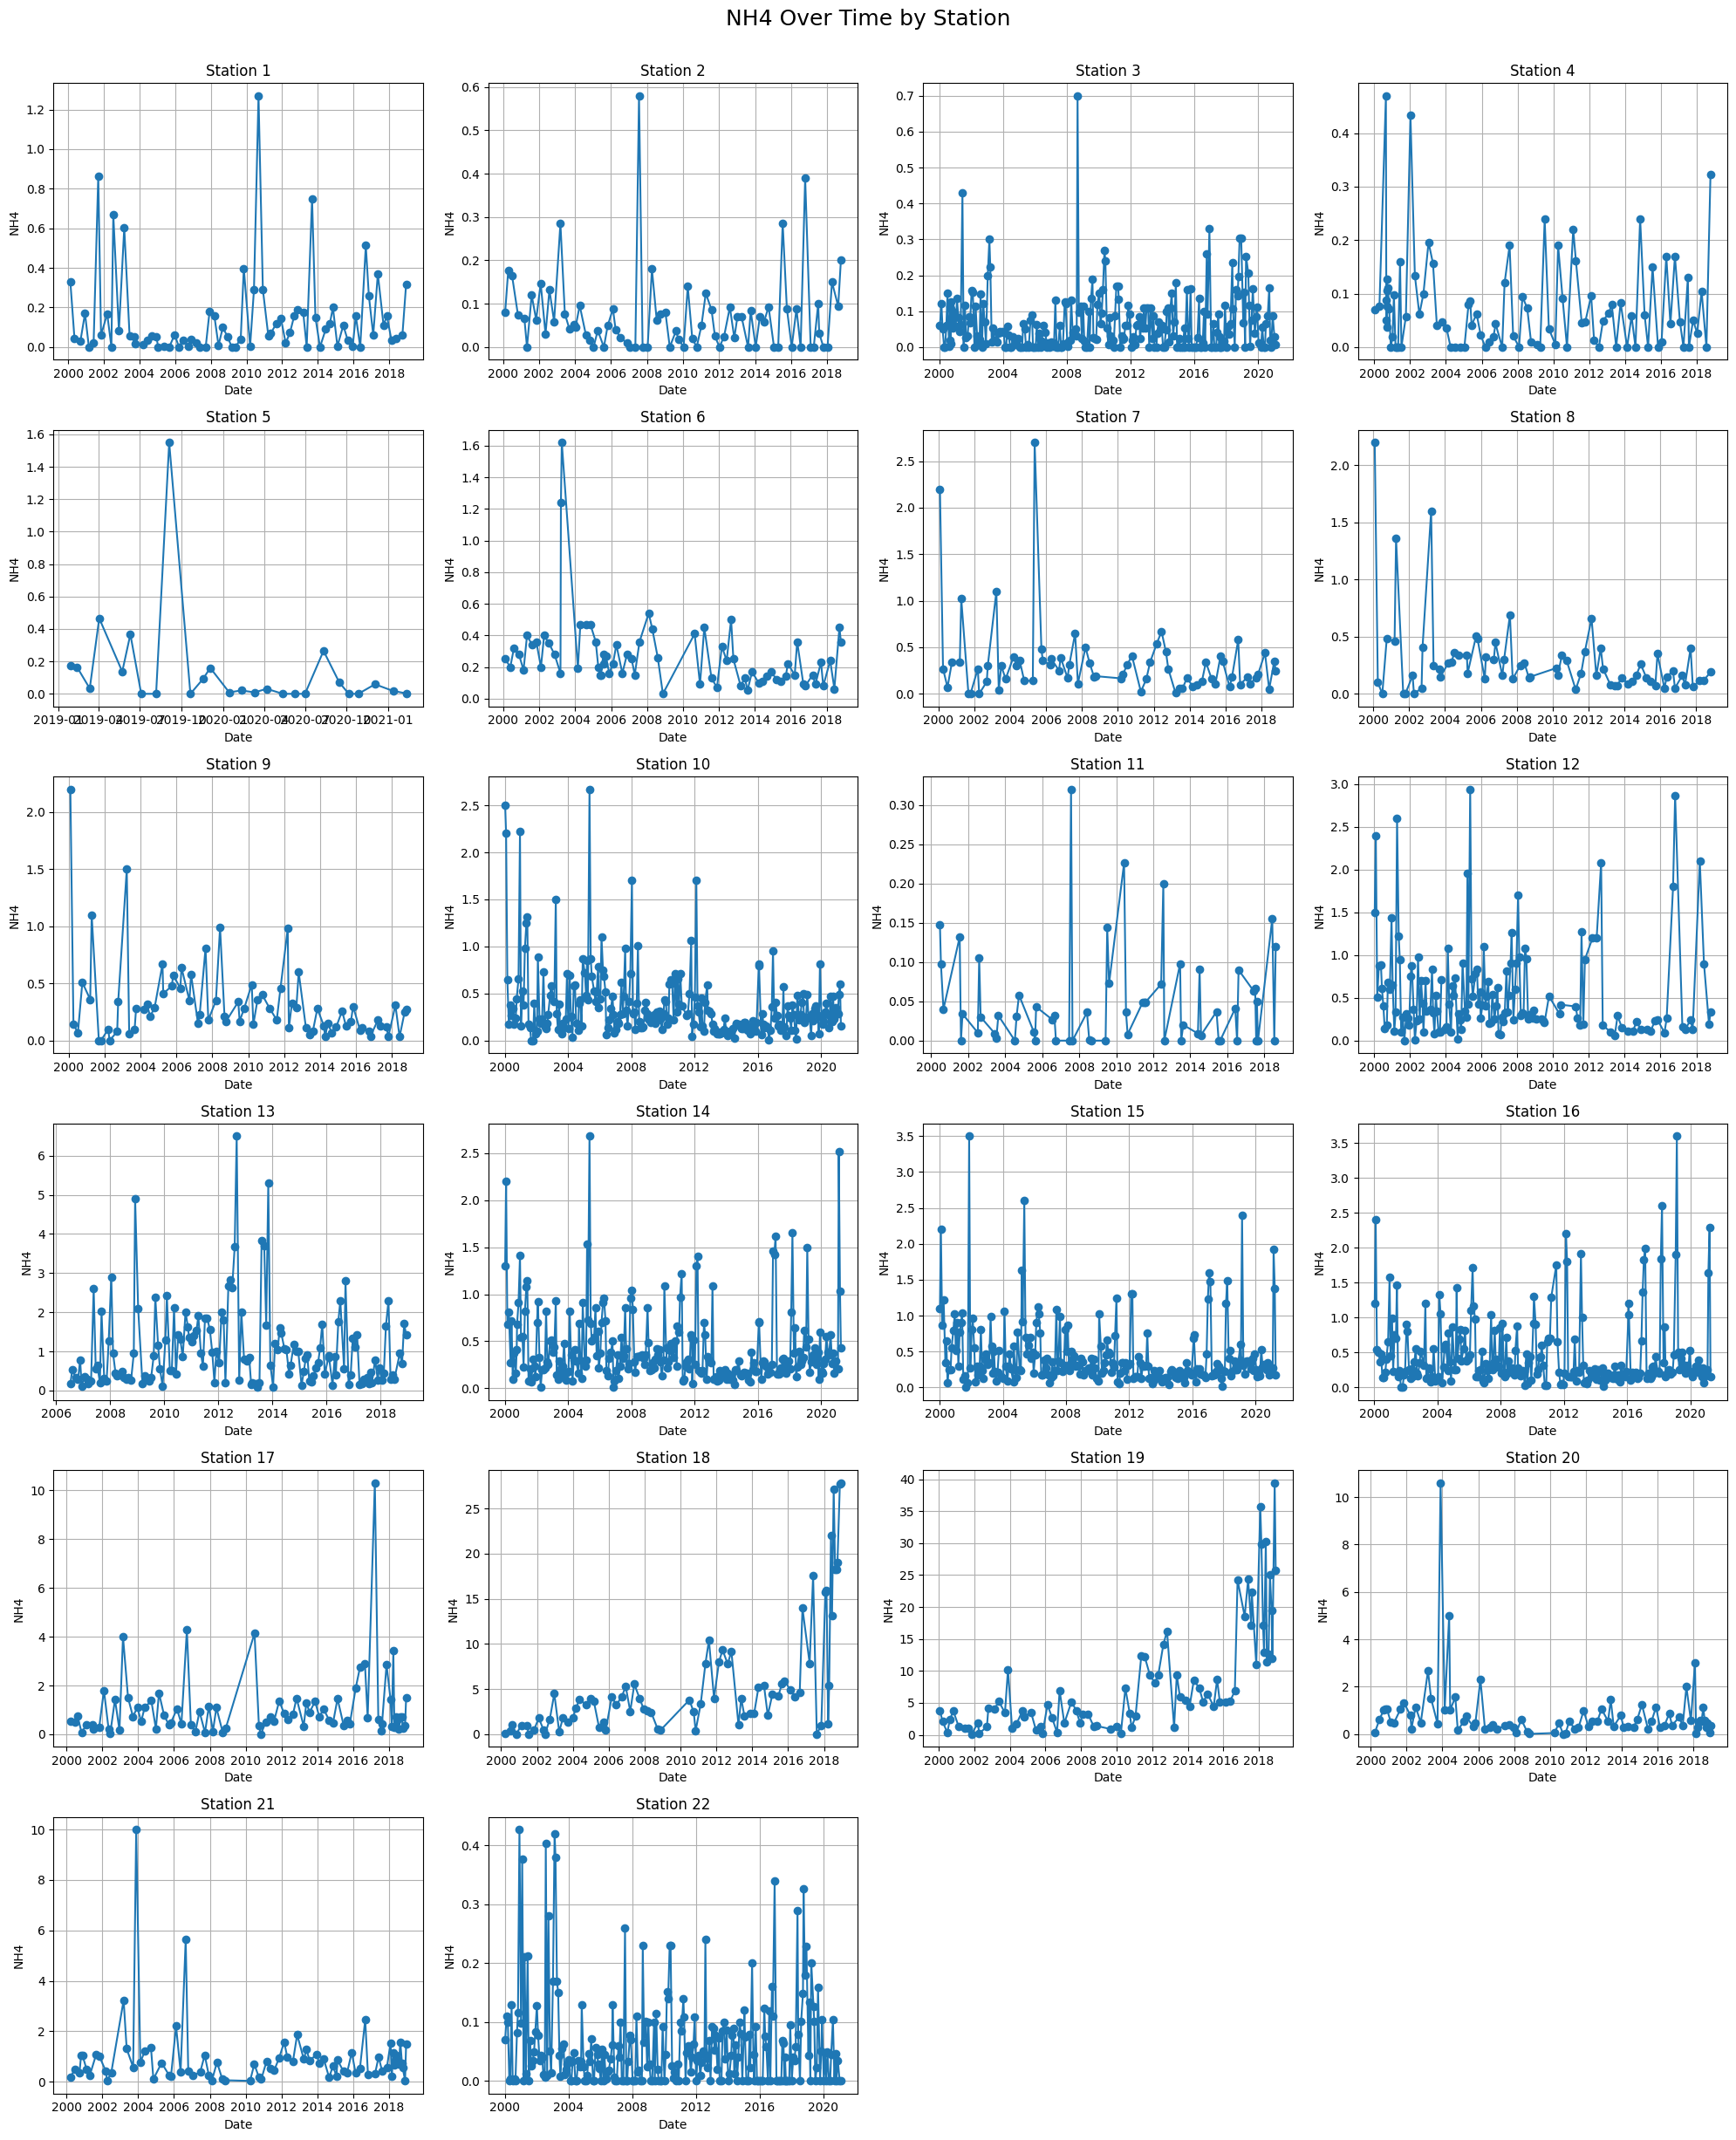

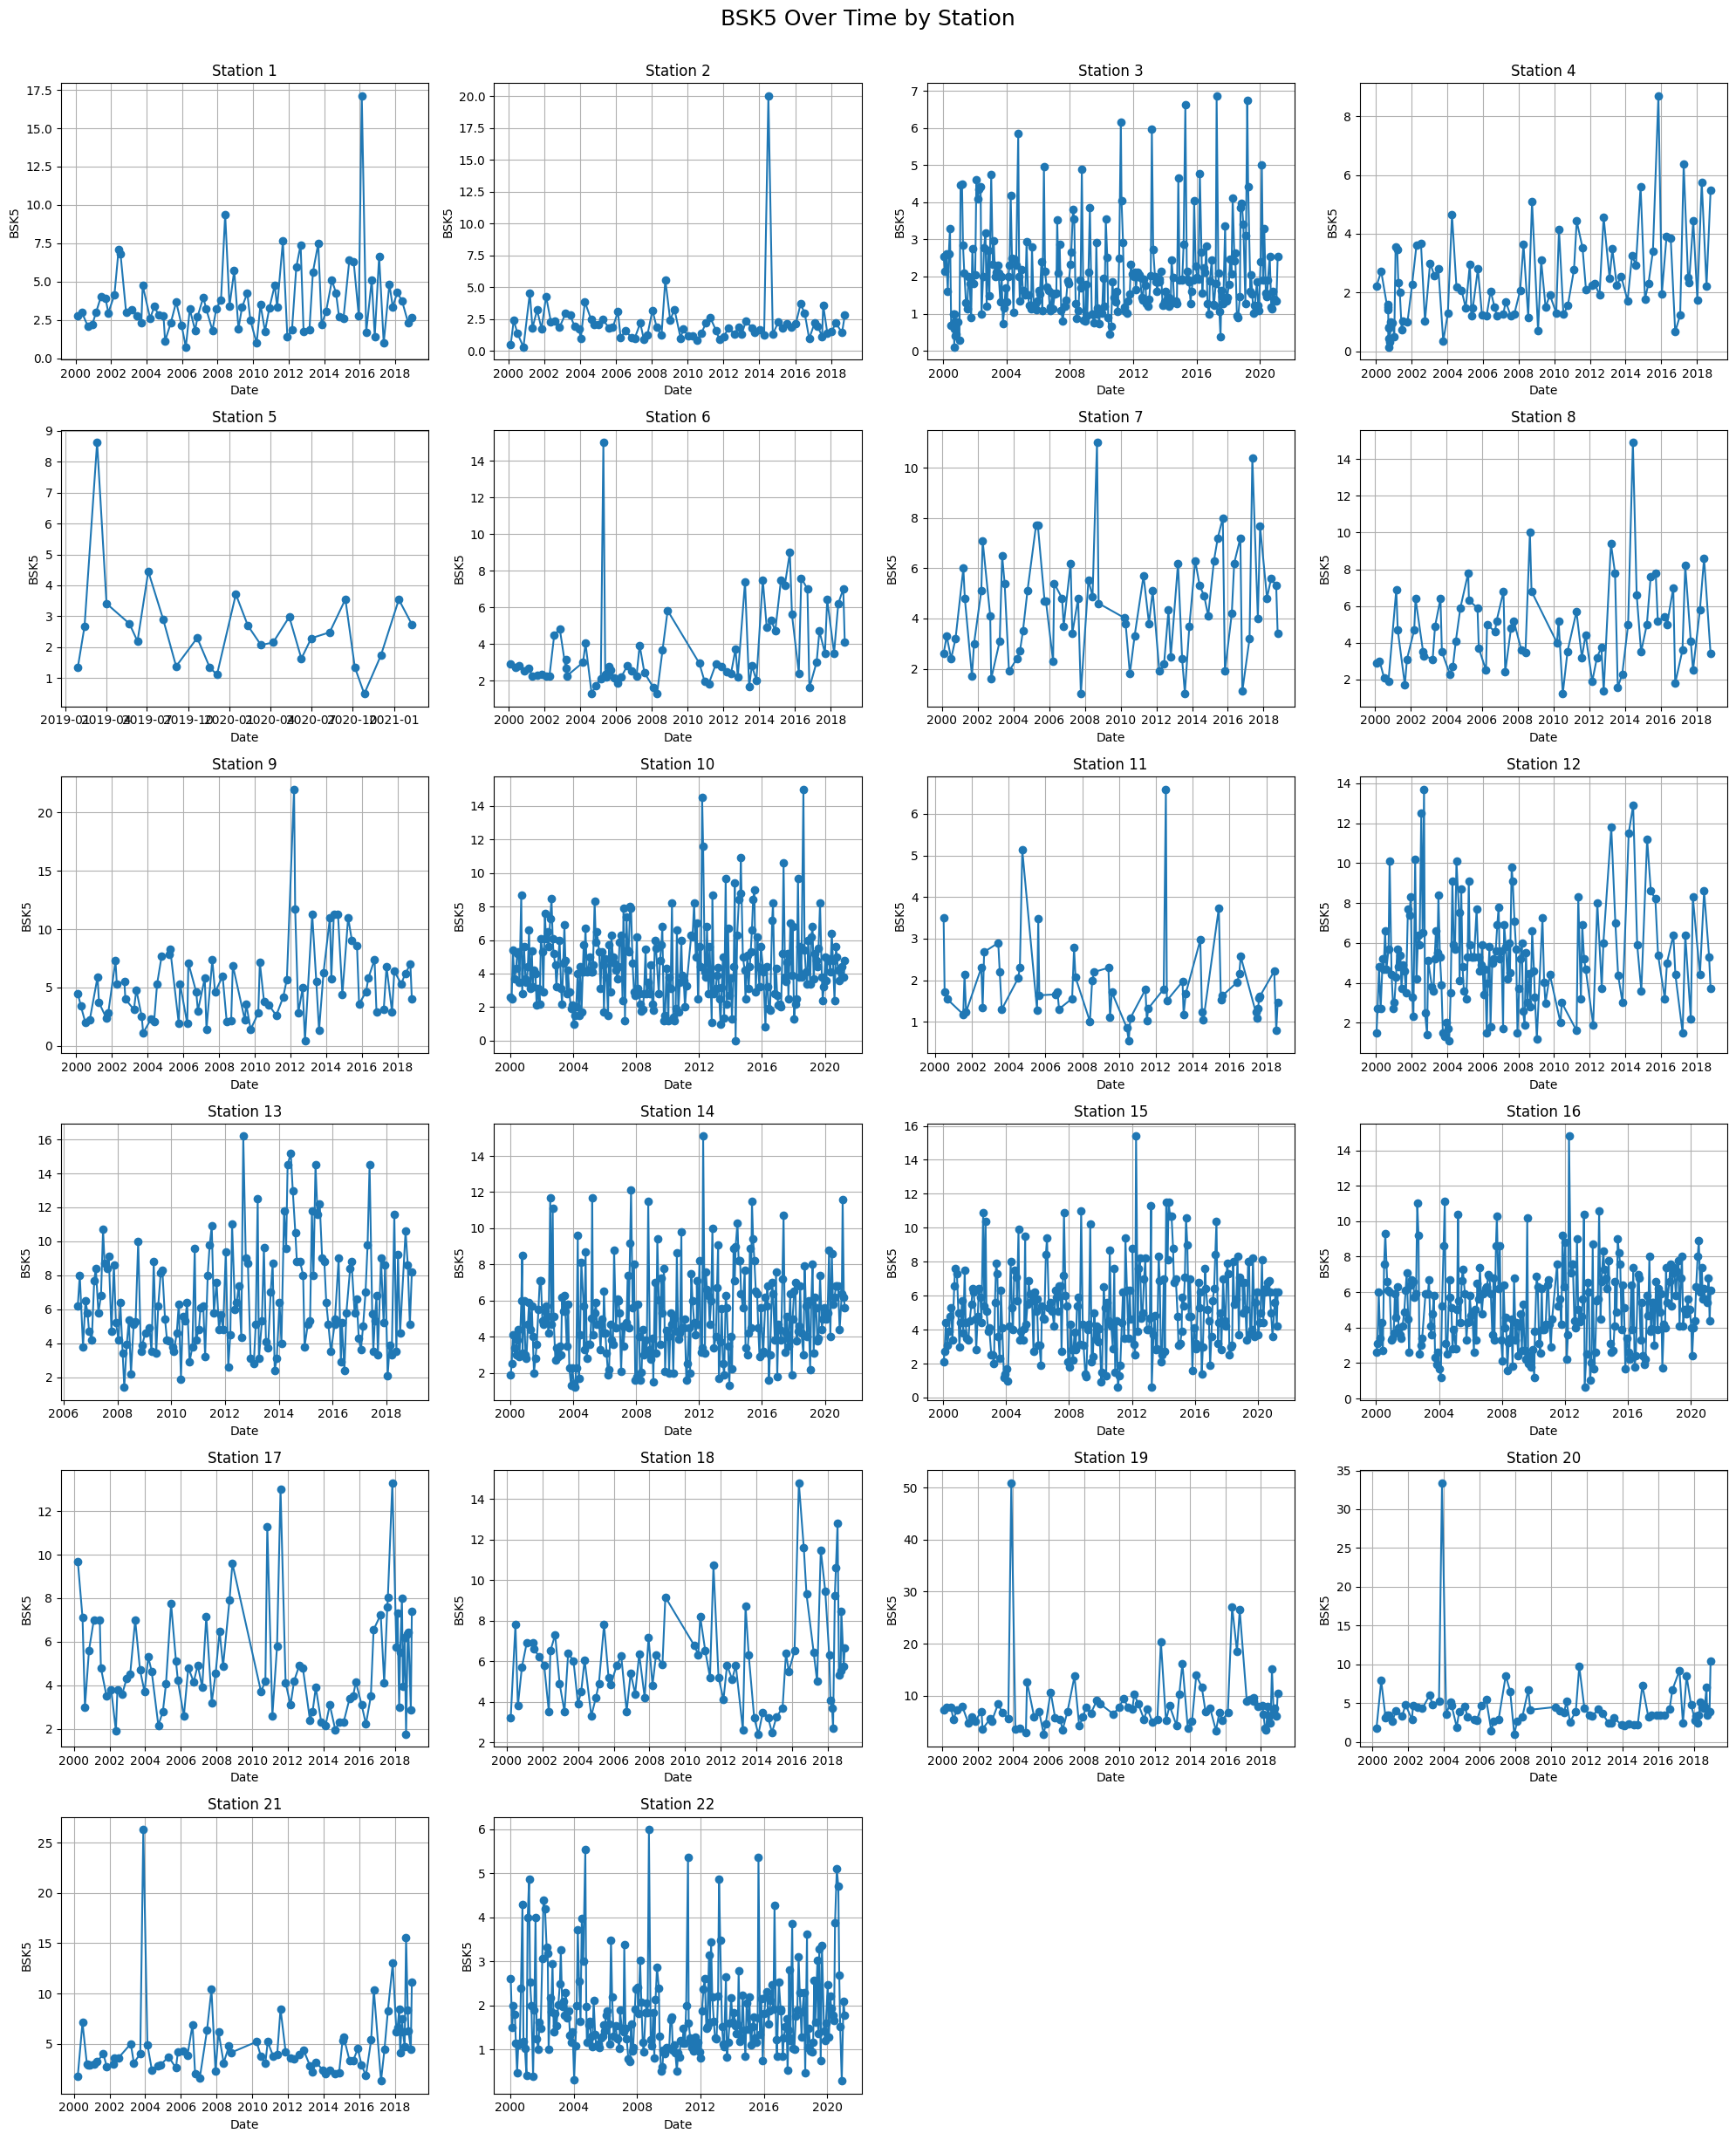

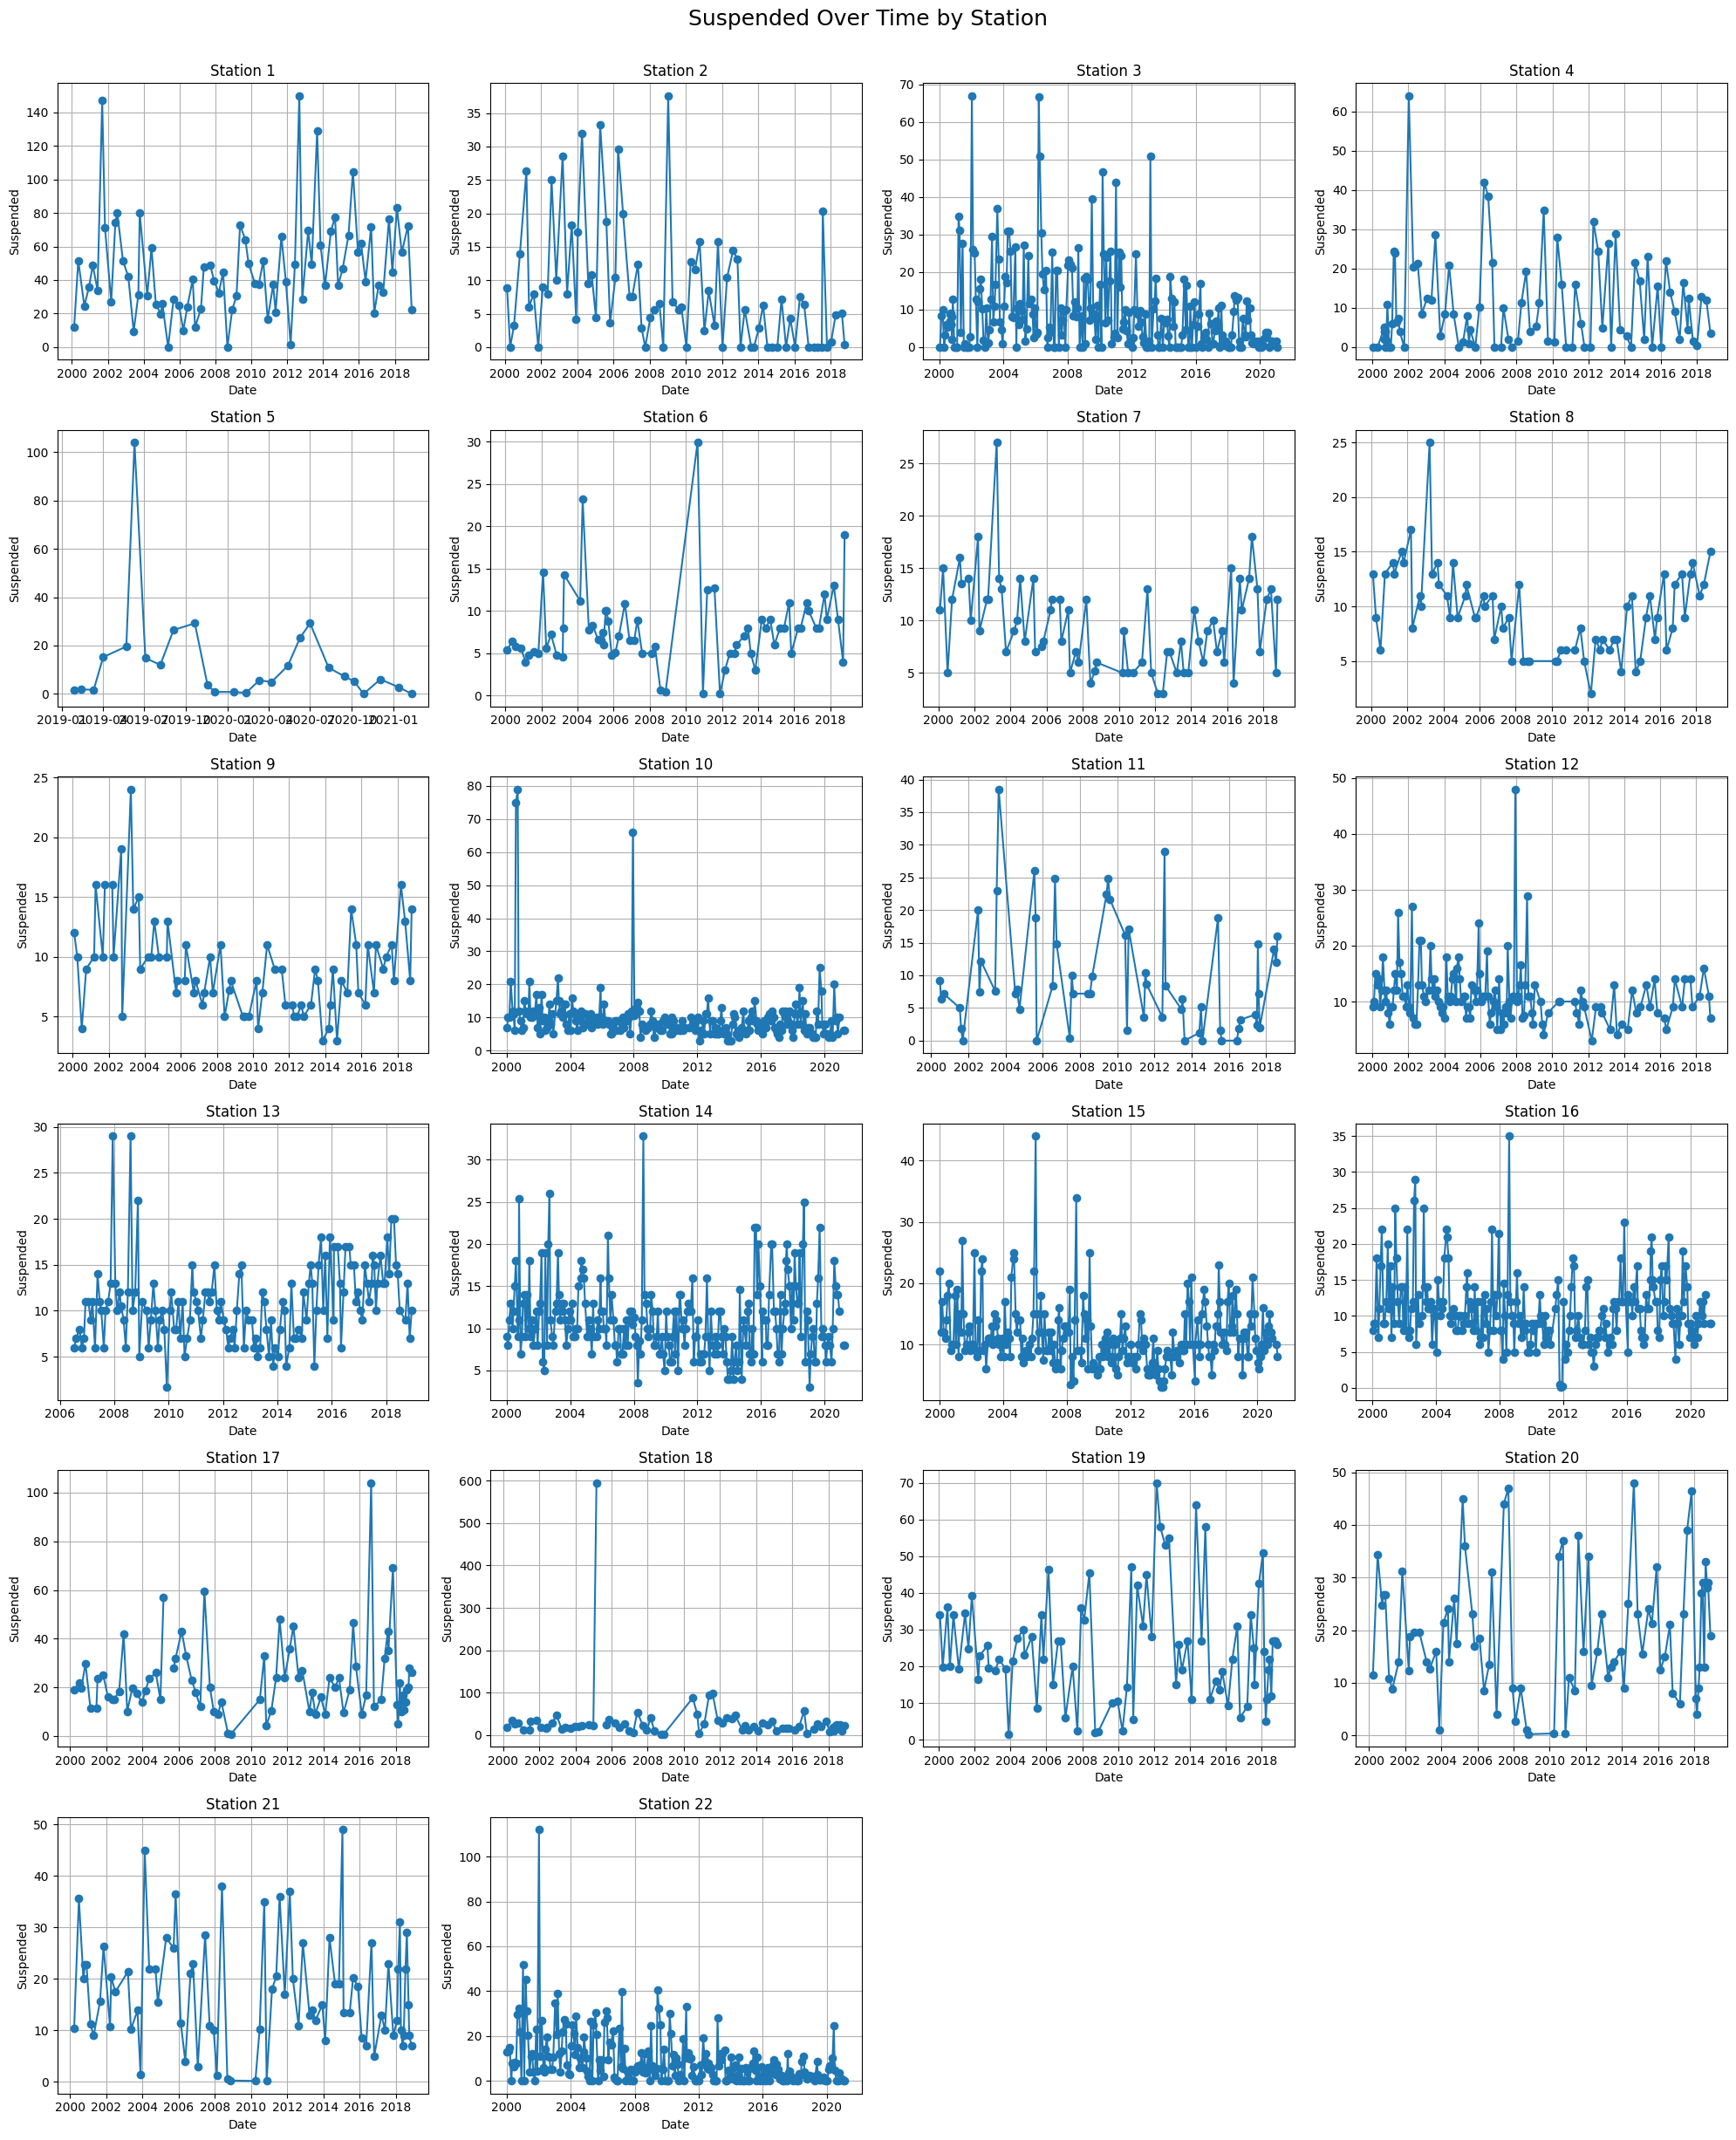

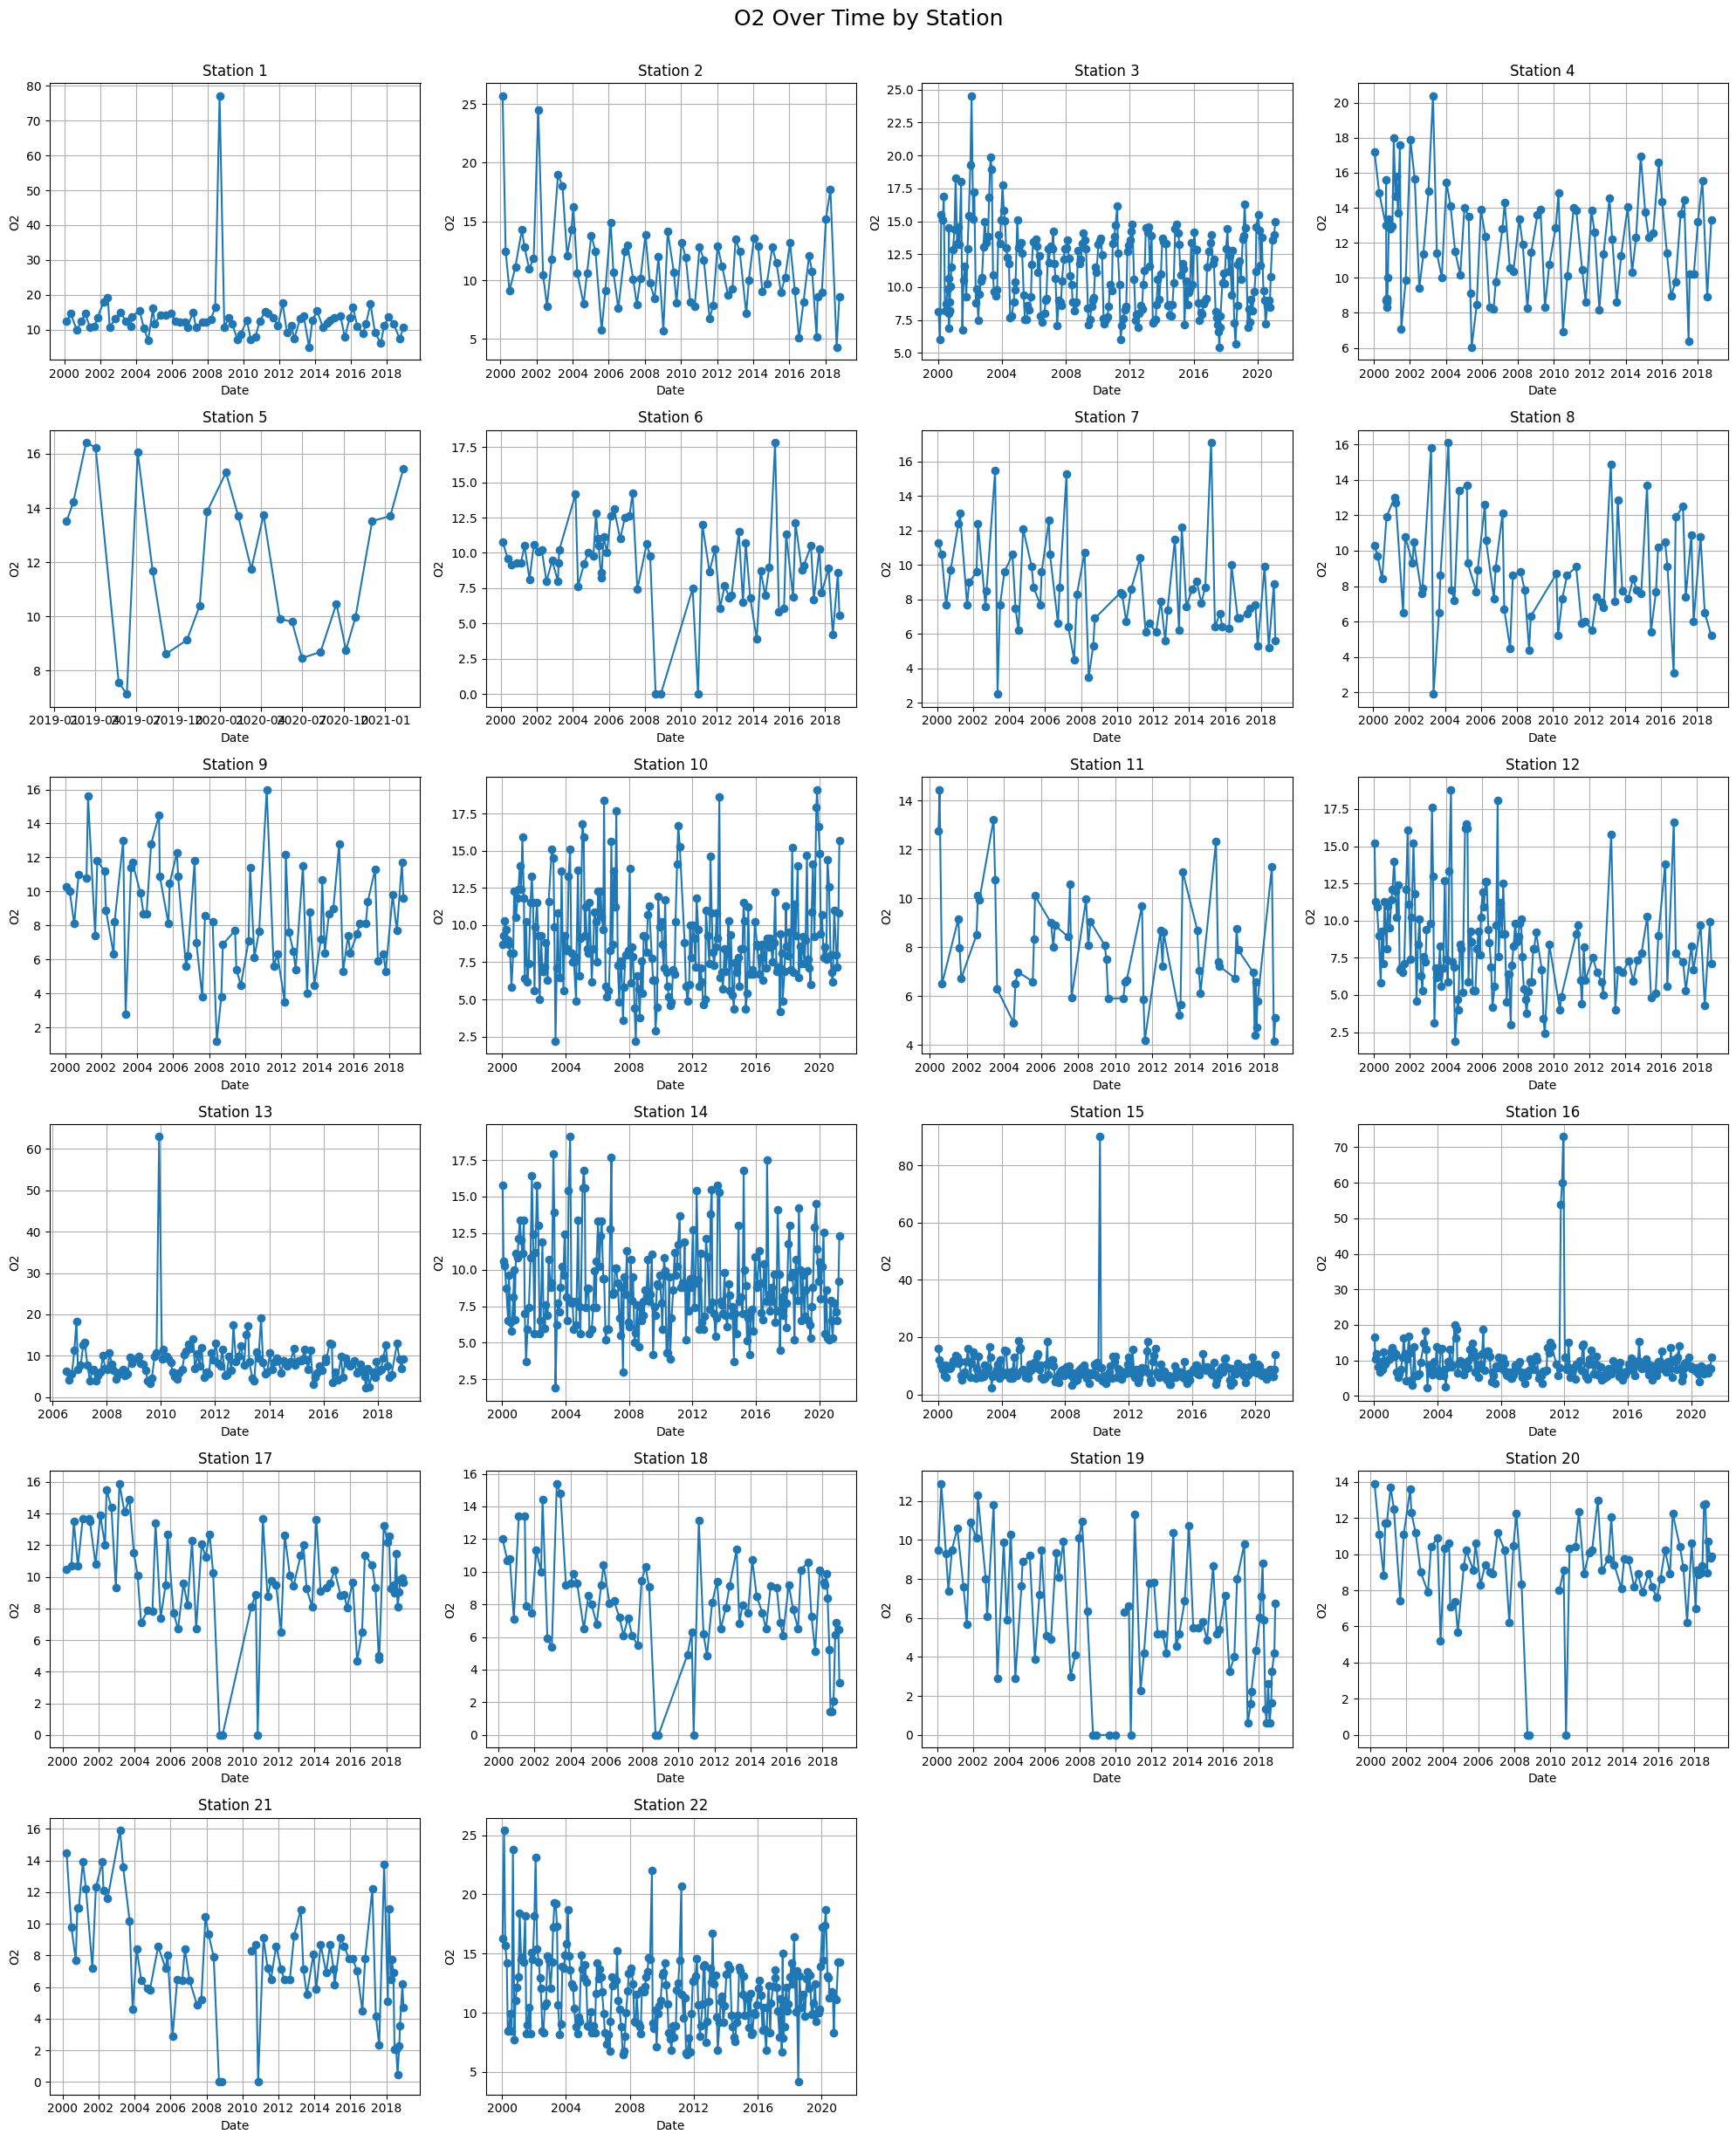

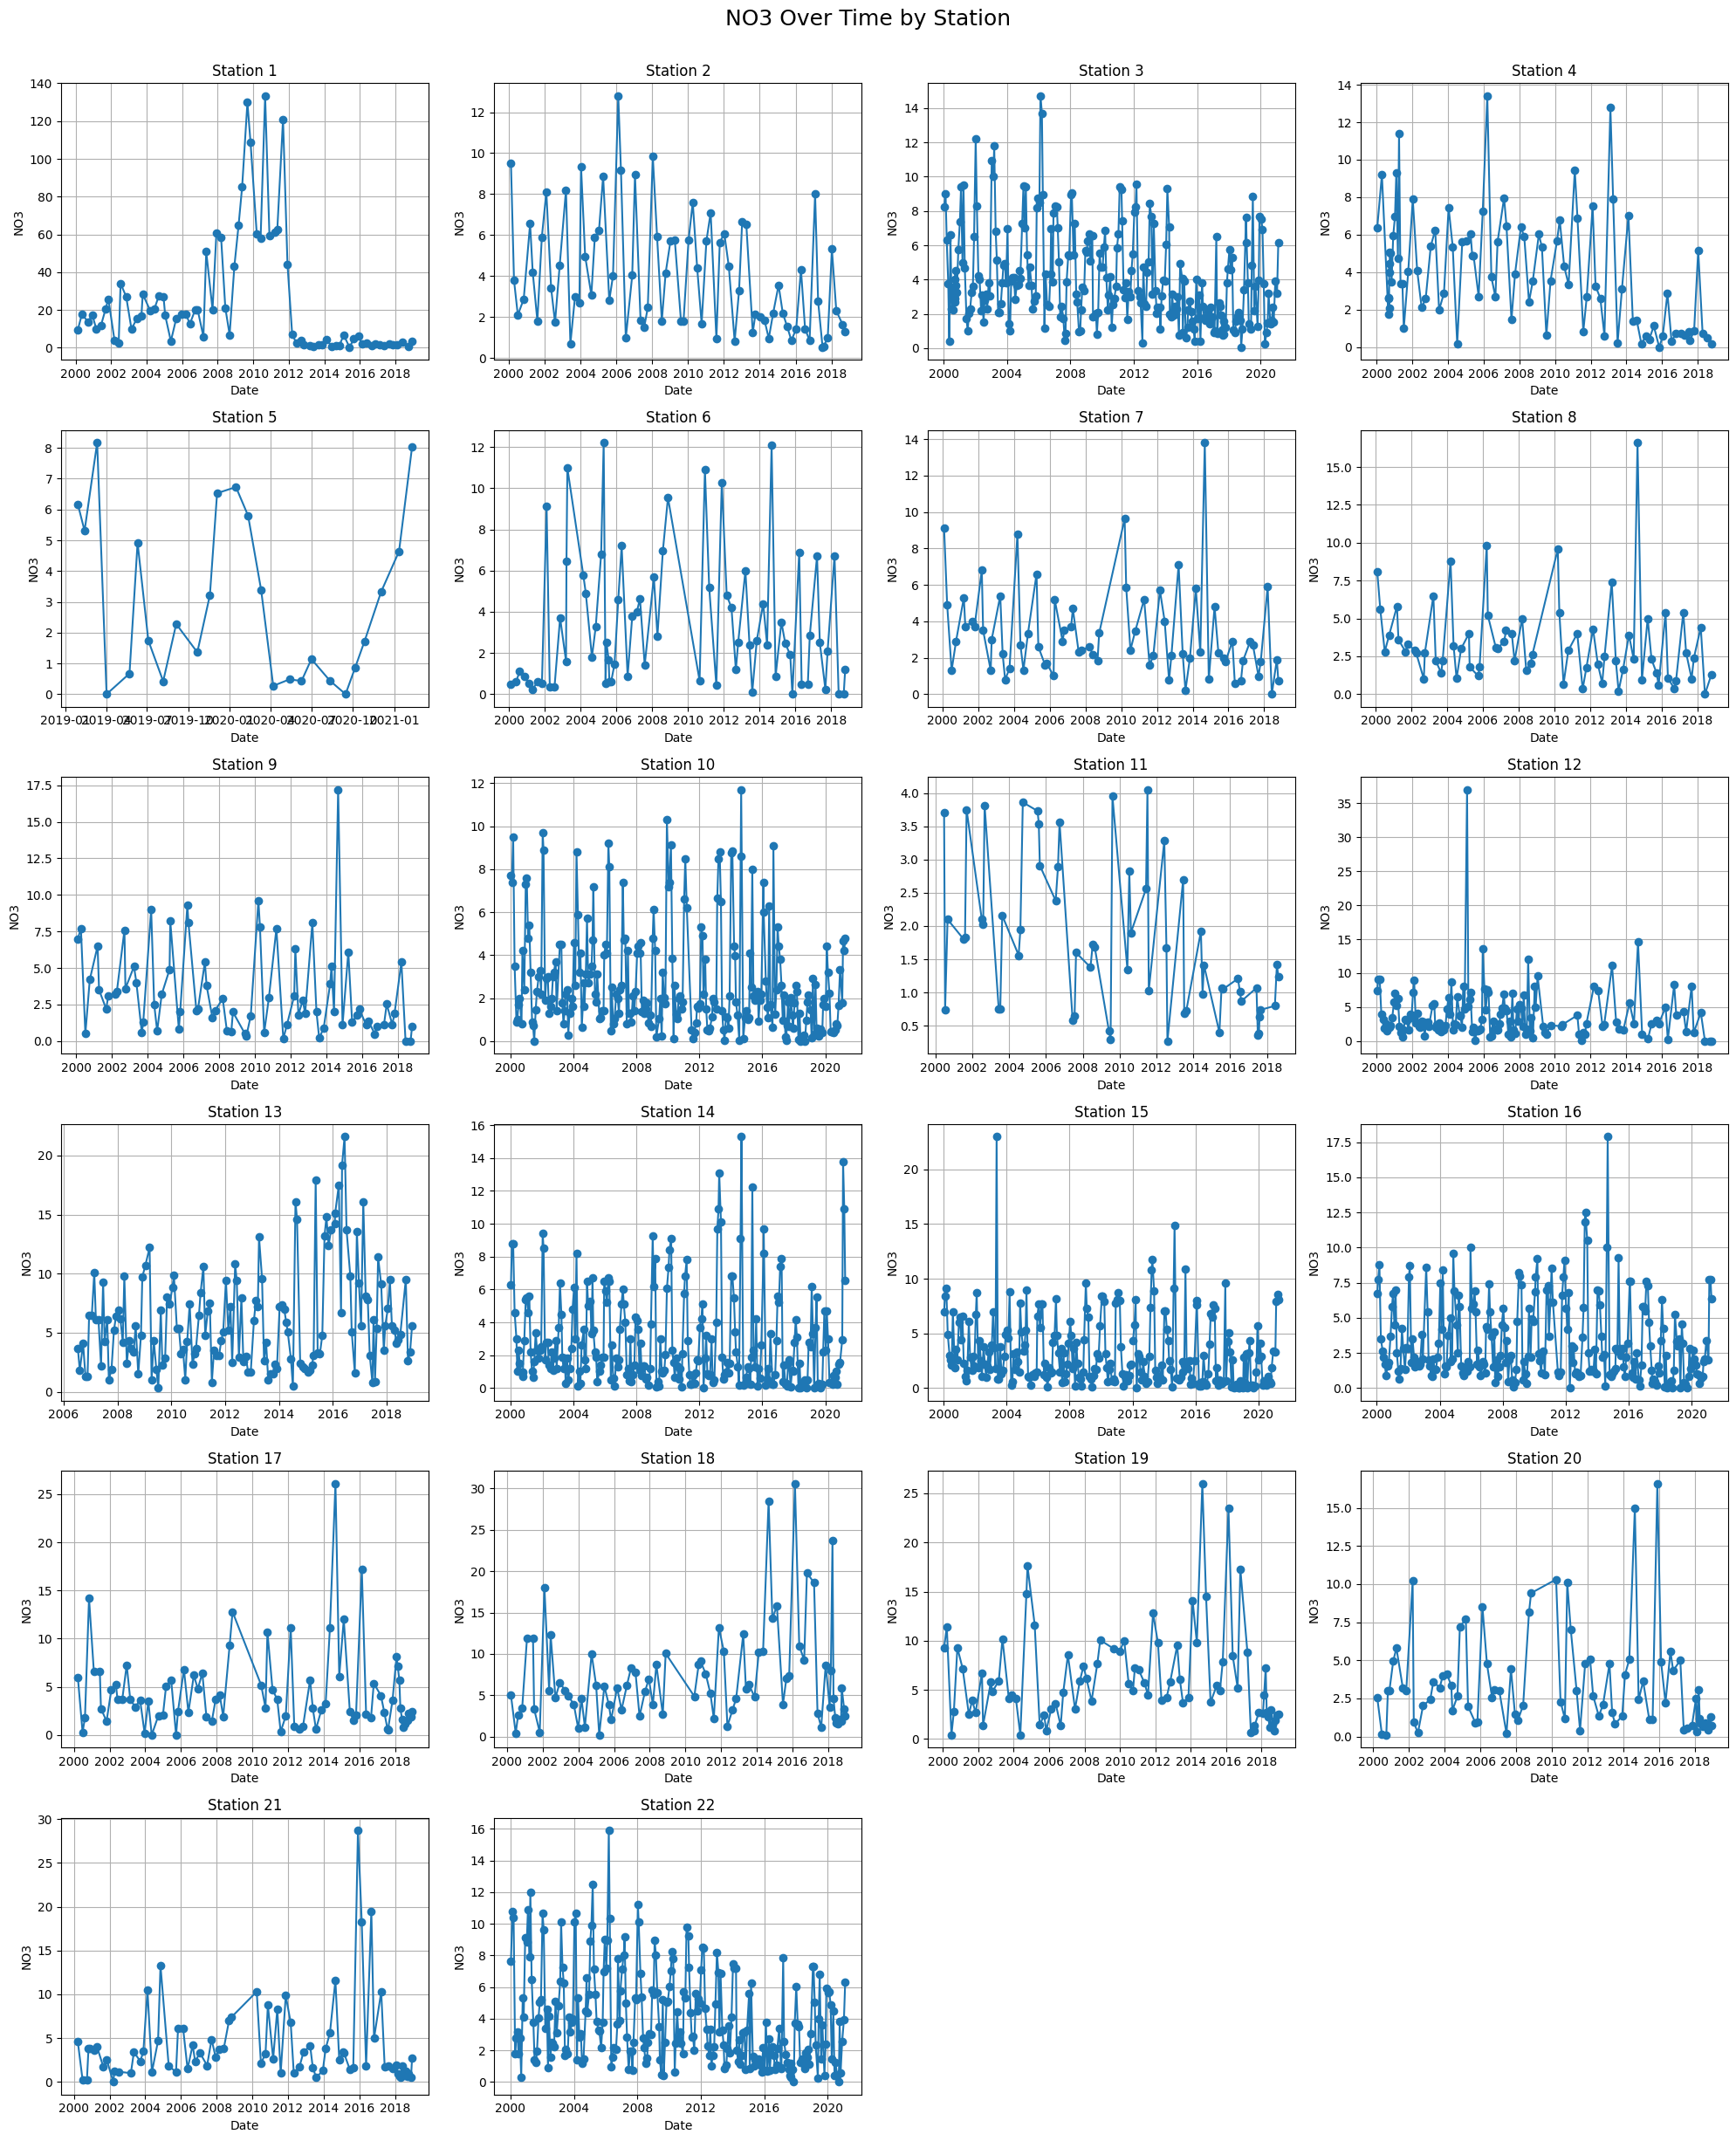

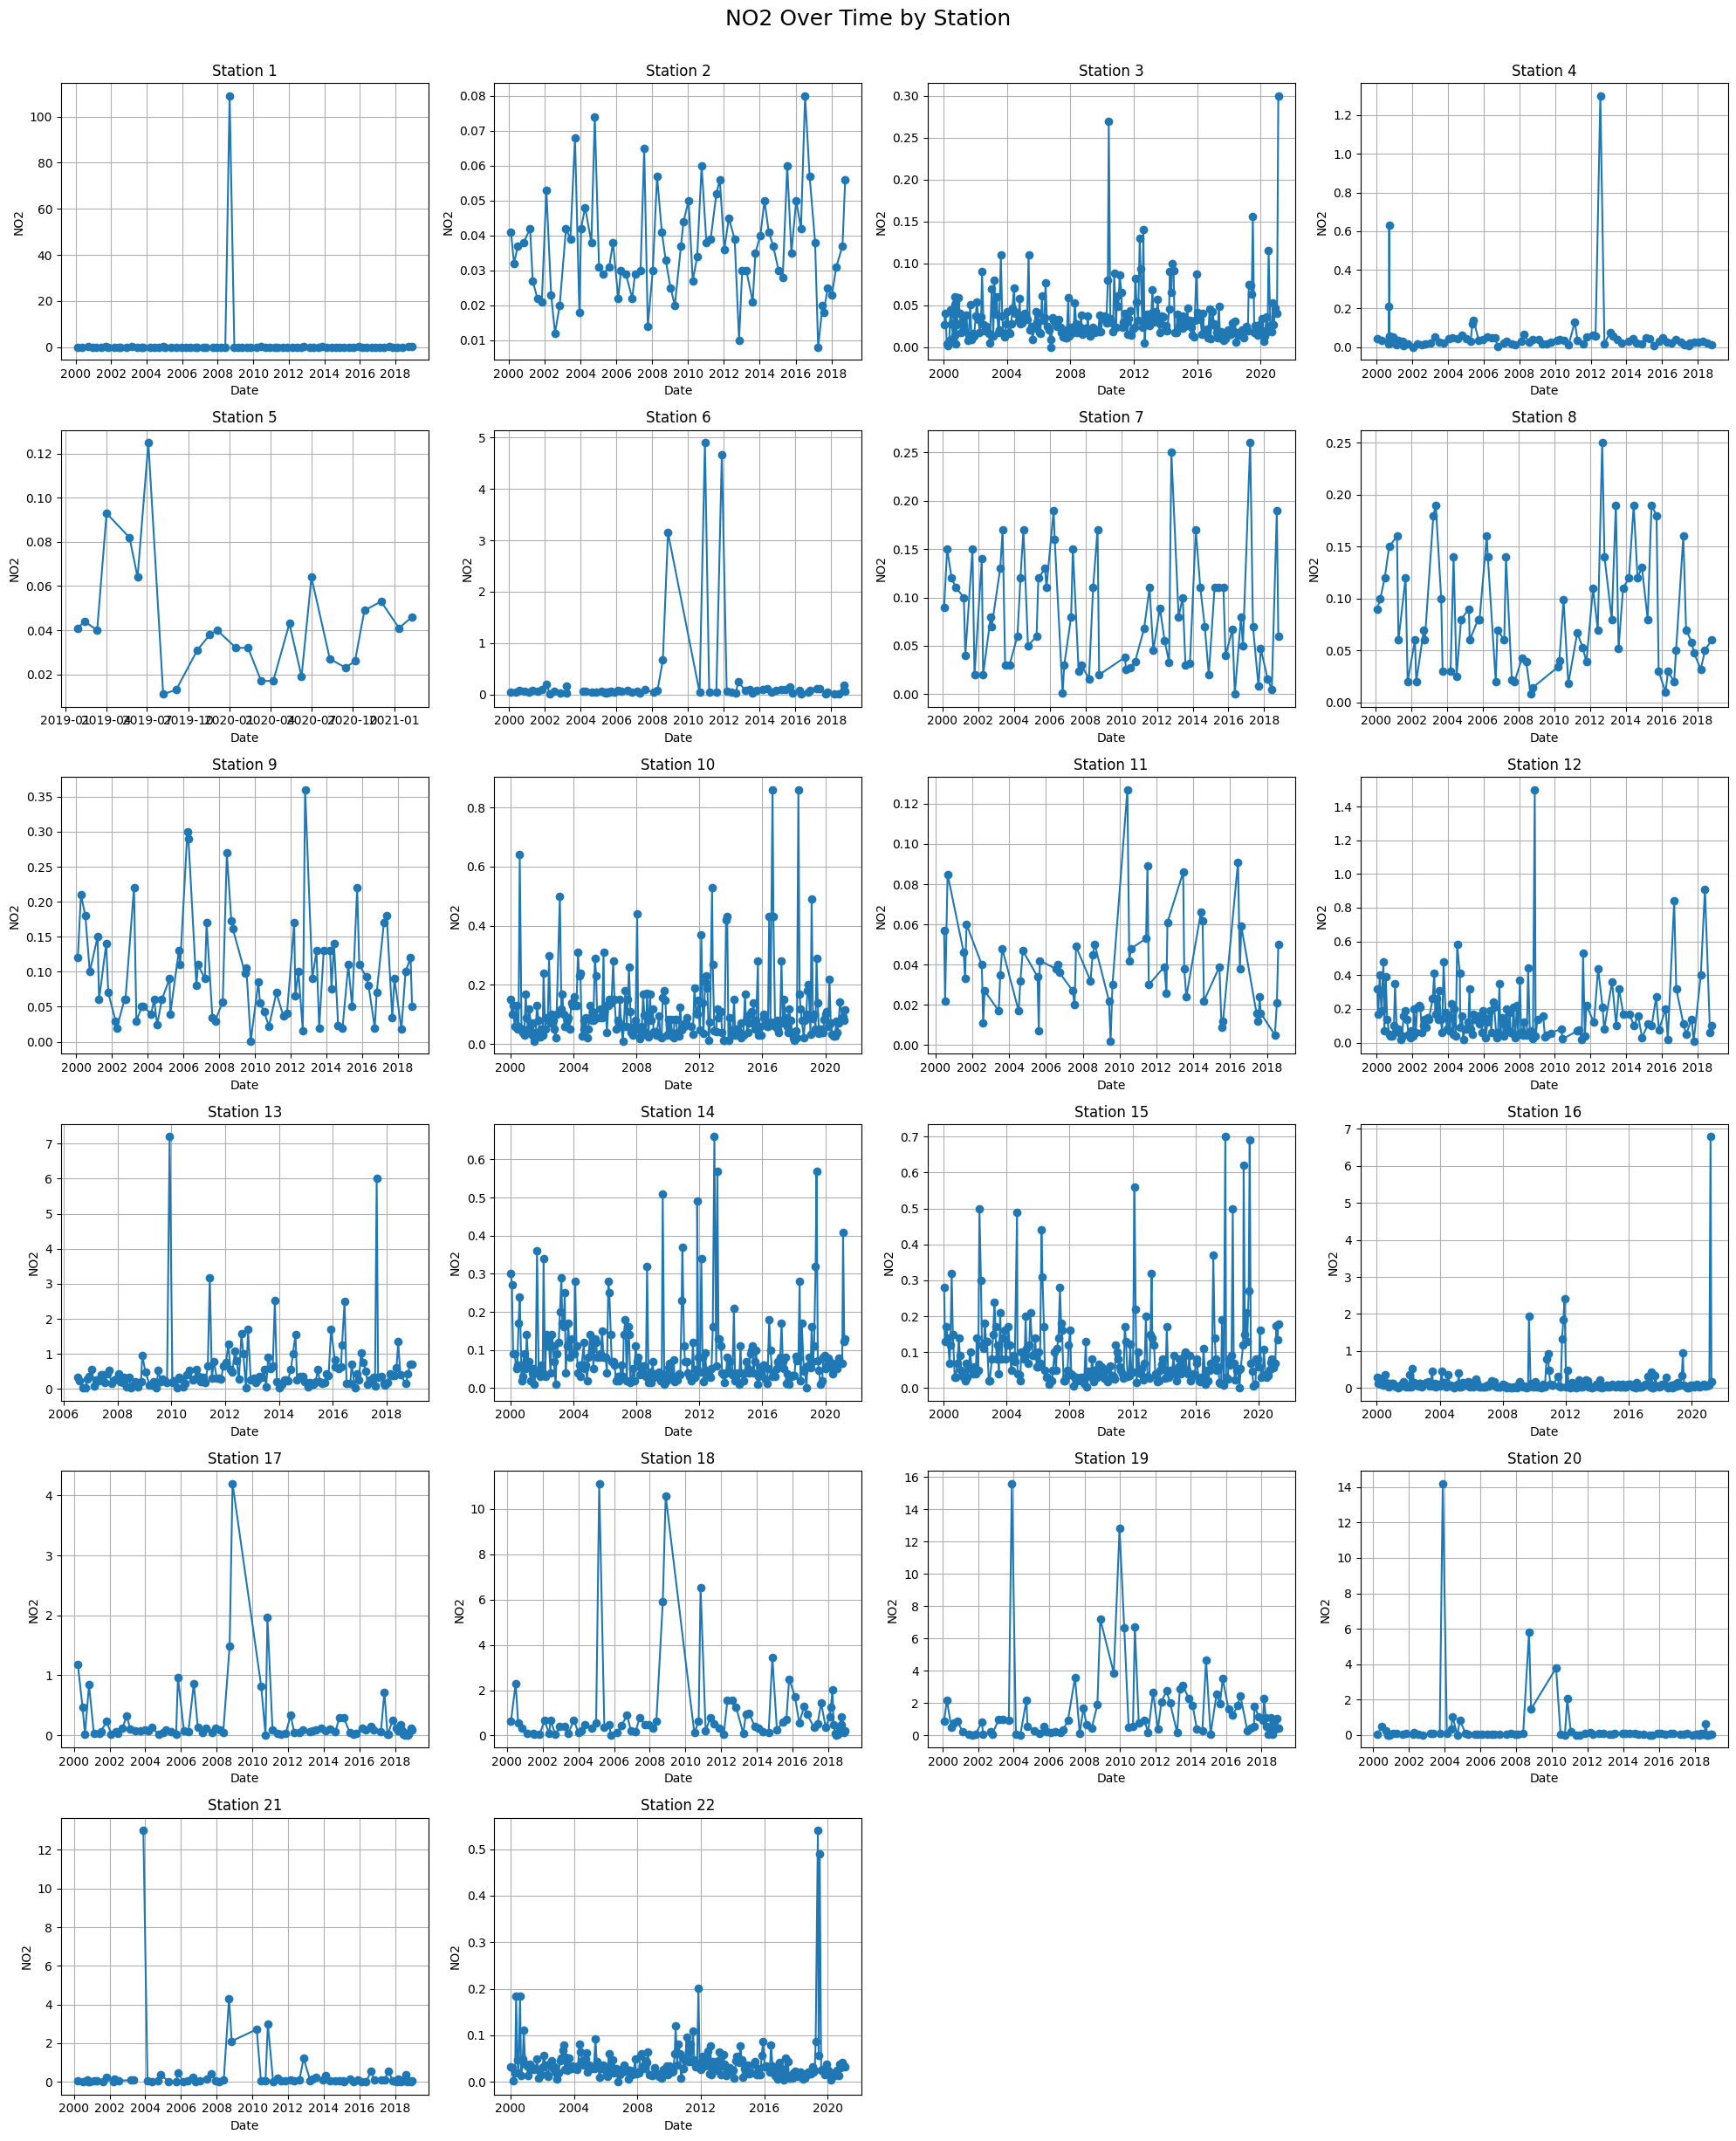

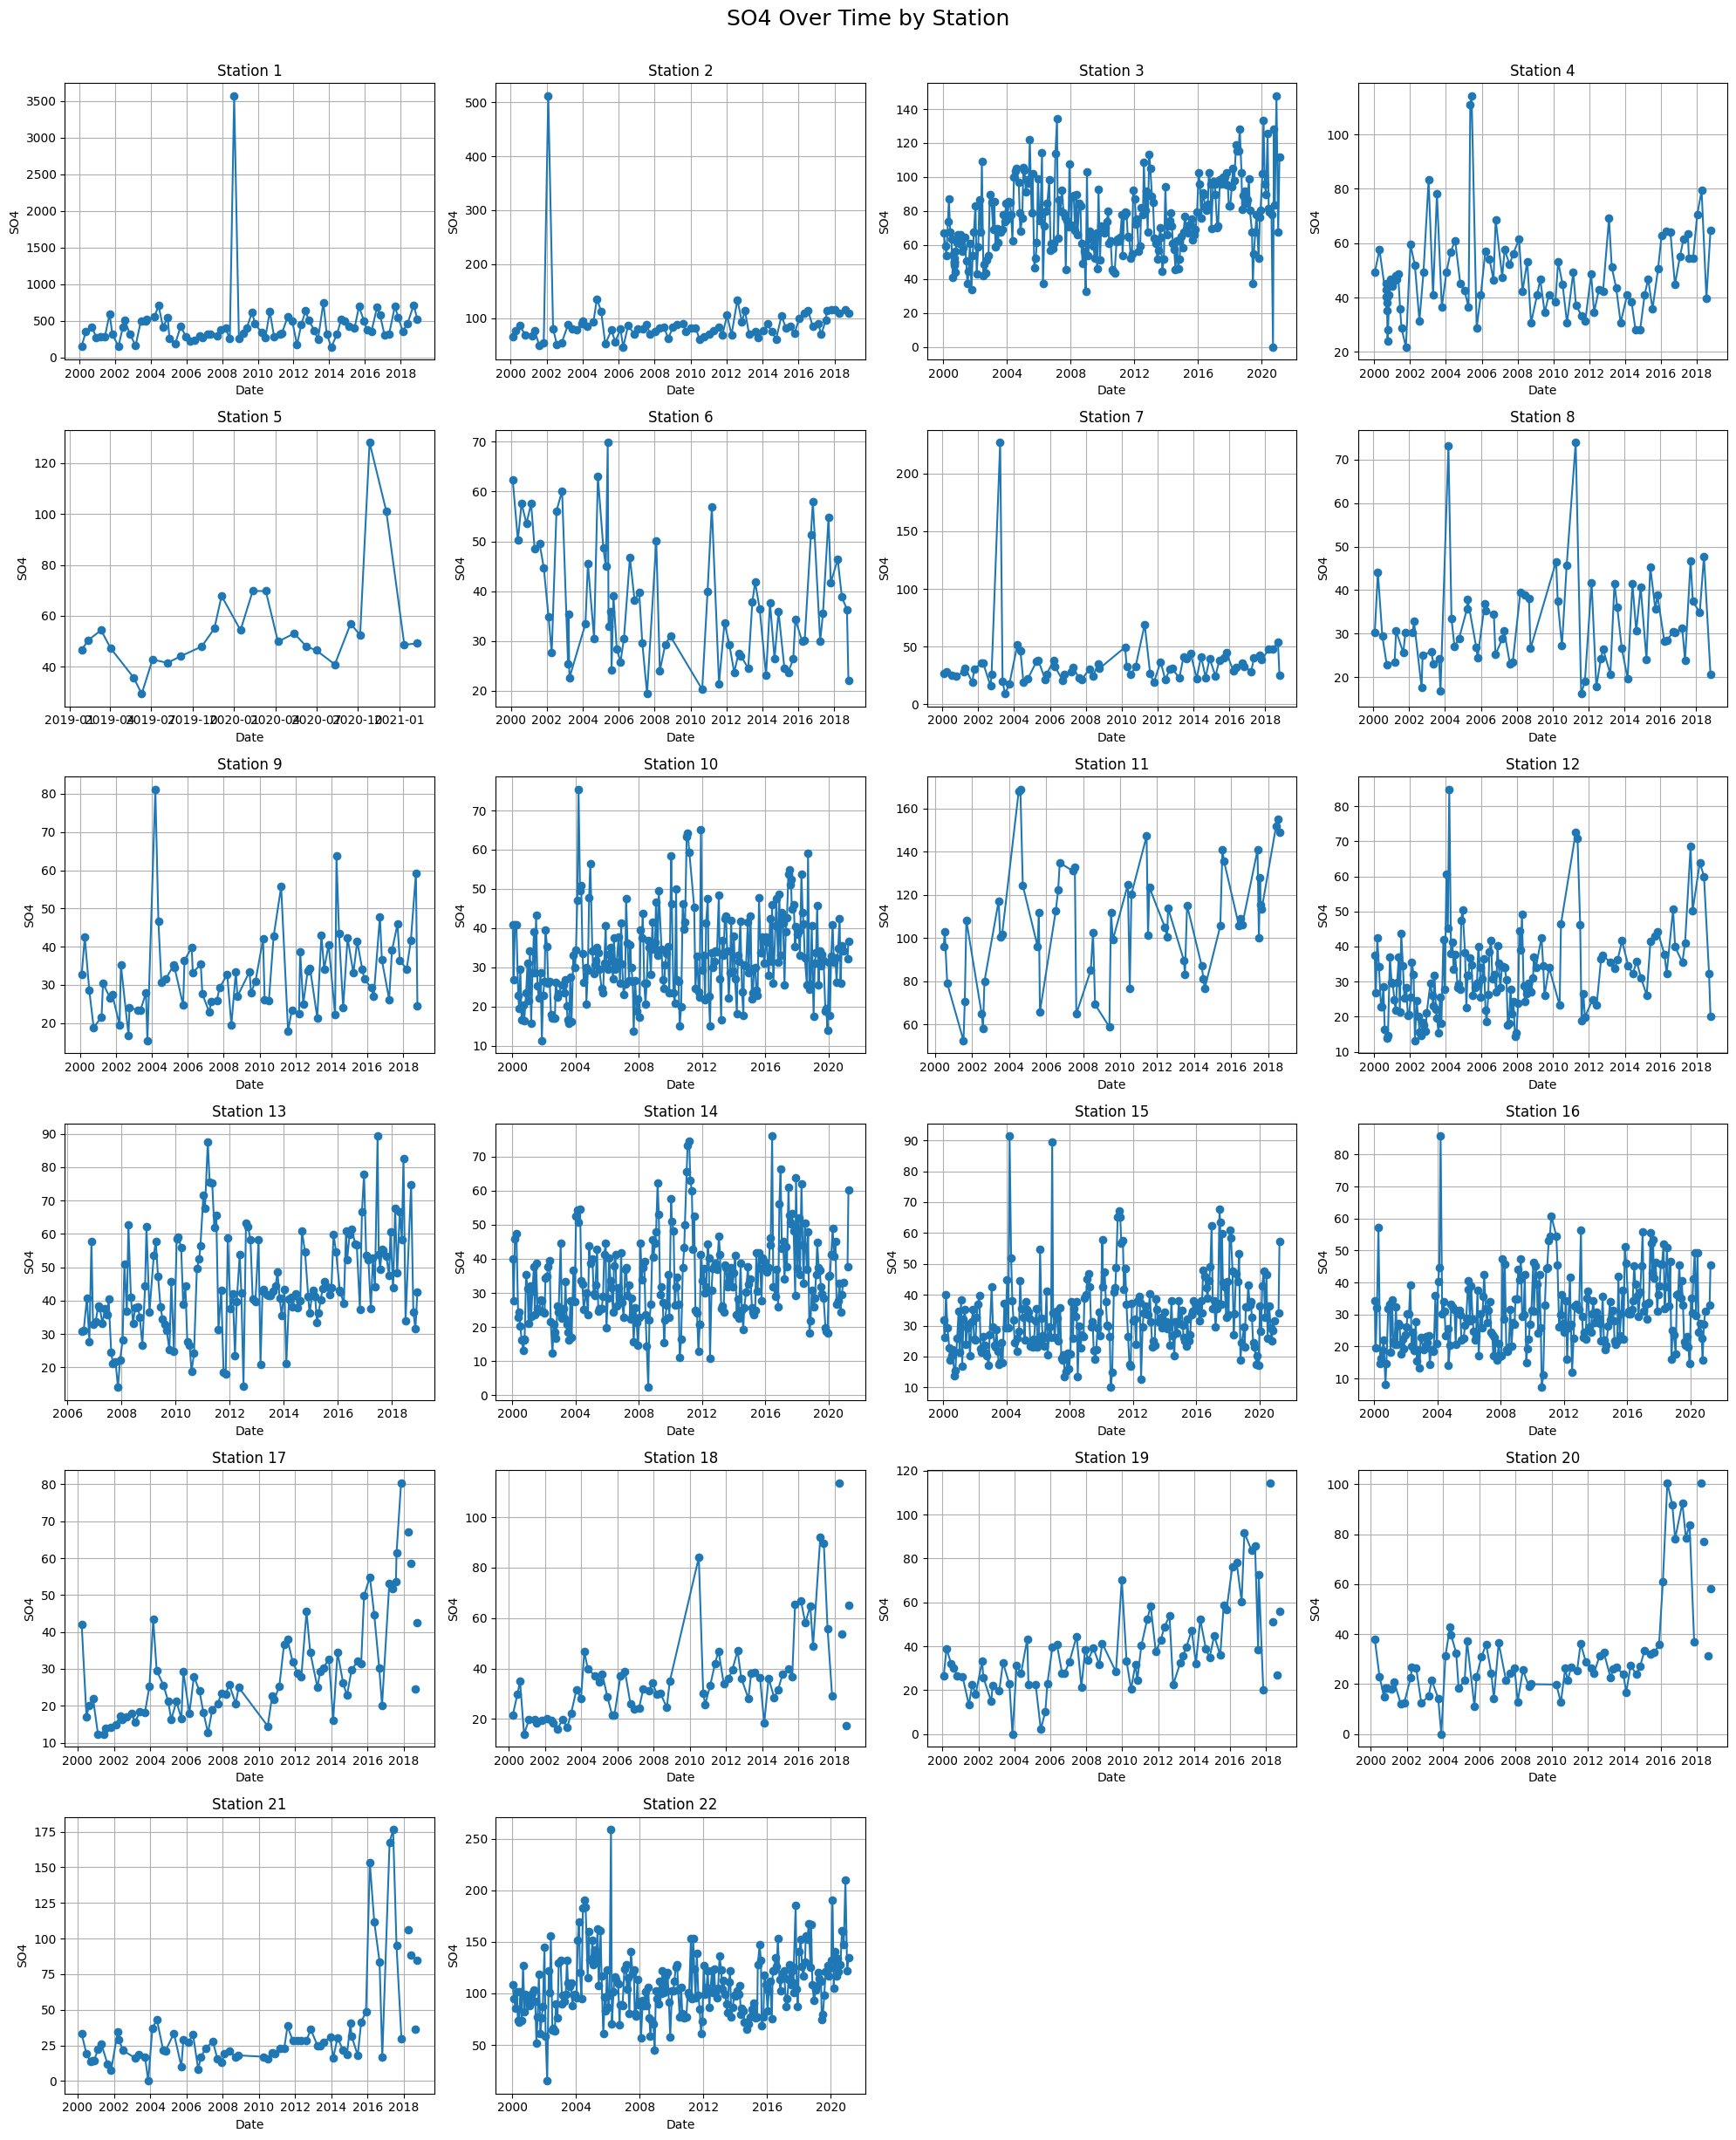

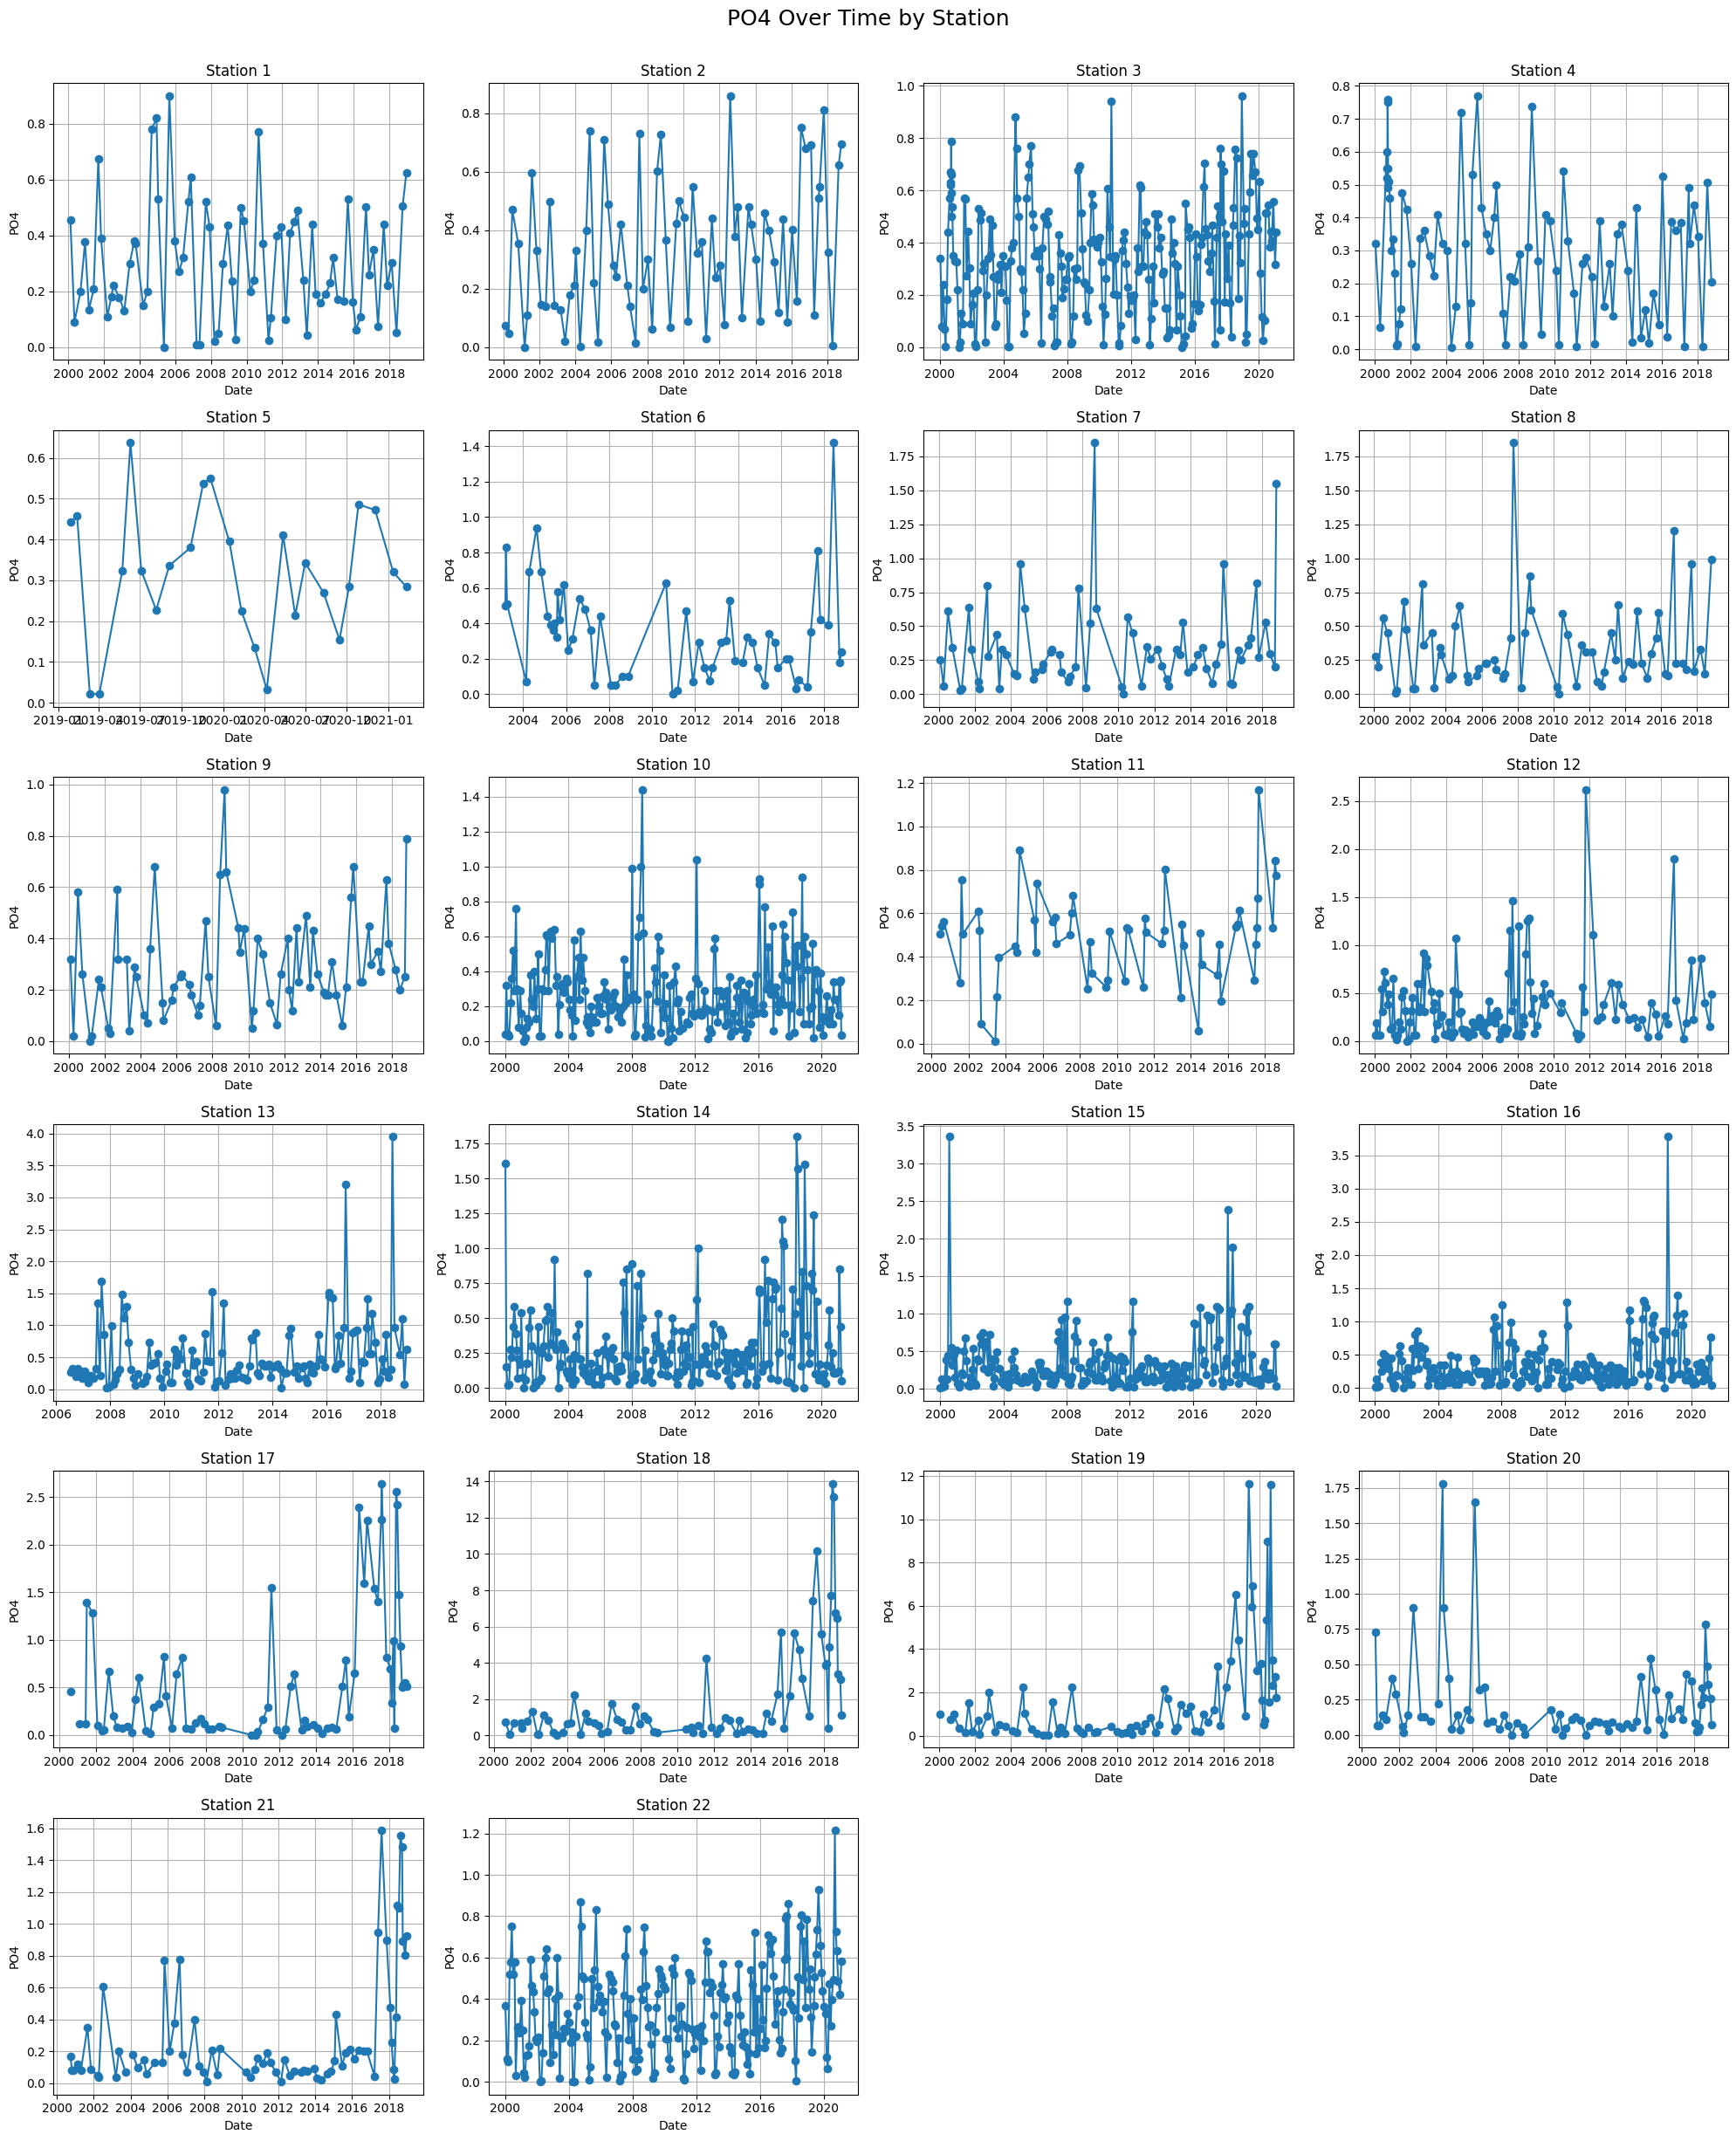

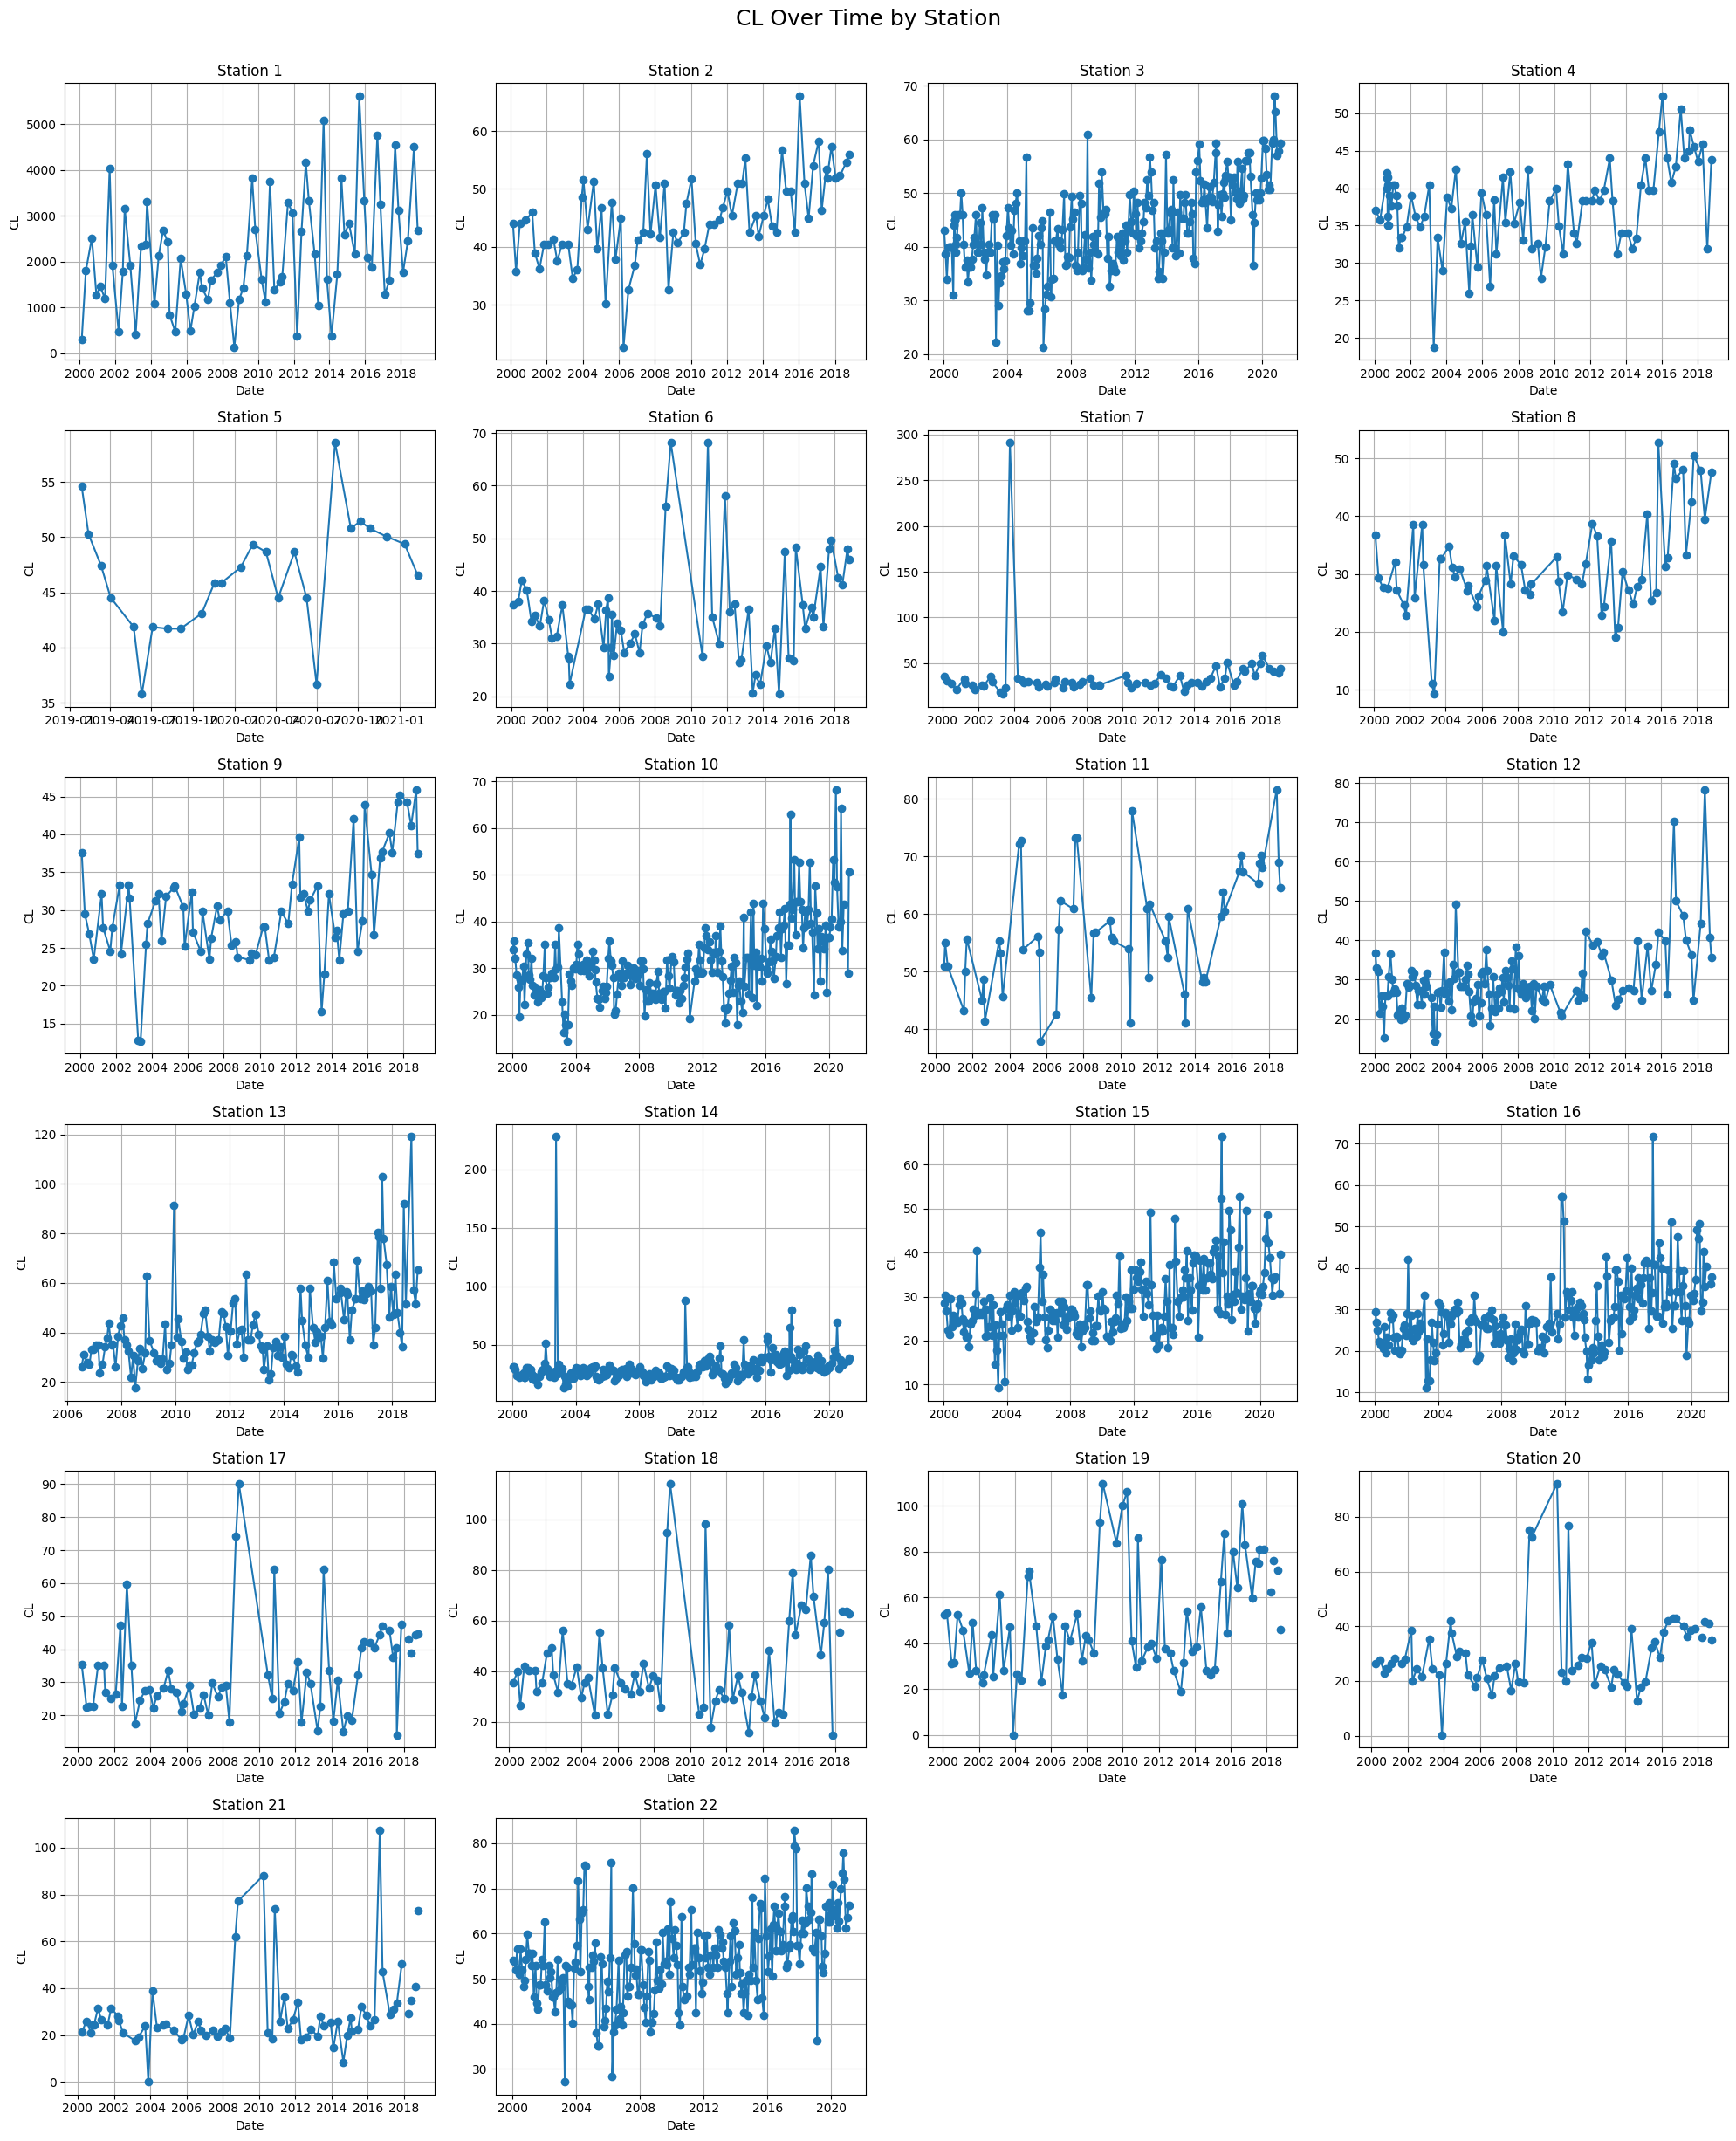

In [20]:
# there are 22 stations
cols = 4
rows = 6

for col in components:
  plt.figure(figsize=(5 * cols, 4 * rows))

  for i, station in enumerate(station_ids, 1):
    plt.subplot(rows, cols, i)
    station_df = df[df['id'] == station]
    plt.plot(station_df['date'], station_df[col], marker='o', linestyle='-')
    plt.title(f'Station {station}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)

  plt.tight_layout()
  plt.suptitle(f'{col} Over Time by Station', fontsize=18, y=1.02)
  plt.show()

WEEK2

In [21]:
pollutants = ['O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL']

In [22]:
# dropping the missing values
df = df.dropna(subset=pollutants)
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5,2000,2
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0,2000,5
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0,2000,9
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0,2000,12
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0,2001,3


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2780 entries, 0 to 2860
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         2780 non-null   int64         
 1   date       2780 non-null   datetime64[ns]
 2   NH4        2778 non-null   float64       
 3   BSK5       2780 non-null   float64       
 4   Suspended  2778 non-null   float64       
 5   O2         2780 non-null   float64       
 6   NO3        2780 non-null   float64       
 7   NO2        2780 non-null   float64       
 8   SO4        2780 non-null   float64       
 9   PO4        2780 non-null   float64       
 10  CL         2780 non-null   float64       
 11  year       2780 non-null   int32         
 12  month      2780 non-null   int32         
dtypes: datetime64[ns](1), float64(9), int32(2), int64(1)
memory usage: 282.3 KB


In [24]:
df.isnull().sum()

id           0
date         0
NH4          2
BSK5         0
Suspended    2
O2           0
NO3          0
NO2          0
SO4          0
PO4          0
CL           0
year         0
month        0
dtype: int64

Model1

In [25]:
# Feature and target selection
X = df[['id', 'year']]
y = df[pollutants]

In [26]:
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True)
X_encoded = X_encoded.astype(int)  # Converting all booleans to integers


In [27]:
X_encoded.dtypes

year     int32
id_2     int32
id_3     int32
id_4     int32
id_5     int32
id_6     int32
id_7     int32
id_8     int32
id_9     int32
id_10    int32
id_11    int32
id_12    int32
id_13    int32
id_14    int32
id_15    int32
id_16    int32
id_17    int32
id_18    int32
id_19    int32
id_20    int32
id_21    int32
id_22    int32
dtype: object

In [28]:
X_encoded

,year,id_2,id_3,id_4,id_5,id_6,id_7,id_8,id_9,id_10,...,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22
0,2000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2856,2020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2857,2020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2858,2020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2859,2021,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [29]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [30]:
# Train the model
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [31]:
# Evaluate model
y_pred = model.predict(X_test)

In [32]:
print("Model Performance on the Test Data:")
for i, pollutant in enumerate(pollutants):
    print(f'{pollutant}:')
    print('   MSE:', mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print('   R2:', r2_score(y_test.iloc[:, i], y_pred[:, i]))
    print()

Model Performance on the Test Data:
O2:
   MSE: 22.21825046040189
   R2: -0.01674257045728833

NO3:
   MSE: 18.153106746365886
   R2: 0.5162032171220556

NO2:
   MSE: 10.607352172601502
   R2: -78.42066512350873

SO4:
   MSE: 2412.139350033052
   R2: 0.4118345603876148

PO4:
   MSE: 0.38496938017964155
   R2: 0.3221189891402043

CL:
   MSE: 34882.81433245622
   R2: 0.7357918194149974



In [33]:
station_id = '22'
year_input = 2024

input_data = pd.DataFrame({'year': [year_input], 'id': [station_id]})
input_encoded = pd.get_dummies(input_data, columns=['id']).astype(int)

# Align with training feature columns
missing_cols = set(X_encoded.columns) - set(input_encoded.columns)
for col in missing_cols:
    input_encoded[col] = 0
input_encoded = input_encoded[X_encoded.columns]  # reorder columns

# Predict pollutants
predicted_pollutants = model.predict(input_encoded)[0]

print(f"\nPredicted pollutant levels for station '{station_id}' in {year_input}:")
for p, val in zip(pollutants, predicted_pollutants):
    print(f"  {p}: {val:.2f}")


Predicted pollutant levels for station '22' in 2024:
  O2: 12.60
  NO3: 6.90
  NO2: 0.13
  SO4: 143.08
  PO4: 0.50
  CL: 67.33


In [34]:
import joblib

joblib.dump(model, 'pollution_model.pkl')
joblib.dump(X_encoded.columns.tolist(), "model_columns.pkl")
print('Model and cols structure are saved!')

Model and cols structure are saved!


Model2

In [35]:
# Feature and target selection
X = df[['id', 'year', 'month']]
y = df[pollutants]

In [36]:
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True)
X_encoded = X_encoded.astype(int)  # Converting all booleans to integers

In [37]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [38]:
# Train the model
model2 = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model2.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [39]:
# Evaluate model
y_pred = model2.predict(X_test)

In [40]:
print("Model Performance on the Test Data:")
for i, pollutant in enumerate(pollutants):
    print(f'{pollutant}:')
    print('   MSE:', mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print('   R2:', r2_score(y_test.iloc[:, i], y_pred[:, i]))
    print()

Model Performance on the Test Data:
O2:
   MSE: 24.945662060318508
   R2: -0.1415532744205239

NO3:
   MSE: 78.34820297914472
   R2: -1.0880507714287861

NO2:
   MSE: 18.796497774656167
   R2: -139.73543811543132

SO4:
   MSE: 8529.783553141193
   R2: -1.0798648690271726

PO4:
   MSE: 0.26832727587041055
   R2: 0.5275105648054128

CL:
   MSE: 285002.74815340963
   R2: -1.1586577514554555



In [41]:
station_id = '22'
year_input = 2024
month_input = 3

input_data = pd.DataFrame({'year': [year_input], 'month': [month_input], 'id': [station_id]})
input_encoded = pd.get_dummies(input_data, columns=['id']).astype(int)

# Align with training feature columns
missing_cols = set(X_encoded.columns) - set(input_encoded.columns)
for col in missing_cols:
    input_encoded[col] = 0
input_encoded = input_encoded[X_encoded.columns]  # reorder columns

# Predict pollutants
predicted_pollutants = model2.predict(input_encoded)[0]

print(f"\nPredicted pollutant levels for station '{station_id}' in {year_input}:")
for p, val in zip(pollutants, predicted_pollutants):
    print(f"  {p}: {val:.2f}")


Predicted pollutant levels for station '22' in 2024:
  O2: 16.84
  NO3: 7.53
  NO2: 0.08
  SO4: 116.25
  PO4: 0.41
  CL: 62.92


Model3

In [42]:
pollutants = ['NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']

In [43]:
# dropping the missing values
df = df.dropna(subset=pollutants)
df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5,2000,2
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0,2000,5
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0,2000,9
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0,2000,12
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0,2001,3


In [44]:
df.isnull().sum()

id           0
date         0
NH4          0
BSK5         0
Suspended    0
O2           0
NO3          0
NO2          0
SO4          0
PO4          0
CL           0
year         0
month        0
dtype: int64

In [45]:
# Feature and target selection
X = df[['id', 'year']]
y = df[pollutants]

In [46]:
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True)
X_encoded = X_encoded.astype(int)  # Converting all booleans to integers

In [47]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [48]:
# Train the model
model3 = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model3.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [49]:
# Evaluate model
y_pred = model3.predict(X_test)

In [50]:
print("Model Performance on the Test Data:")
for i, pollutant in enumerate(pollutants):
    print(f'{pollutant}:')
    print('   MSE:', mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print('   R2:', r2_score(y_test.iloc[:, i], y_pred[:, i]))
    print()

Model Performance on the Test Data:
NH4:
   MSE: 0.8827195364614927
   R2: 0.7801981883484587

BSK5:
   MSE: 5.31094542545559
   R2: 0.19096990064204467

Suspended:
   MSE: 98.17784721522588
   R2: 0.20495839046561737

O2:
   MSE: 13.955930601011778
   R2: 0.05381534726017545

NO3:
   MSE: 20.40490374797047
   R2: 0.484569230962687

NO2:
   MSE: 10.343405404494533
   R2: -58.203860061465534

SO4:
   MSE: 2275.807351900022
   R2: 0.44815941114800695

PO4:
   MSE: 0.24389334027446746
   R2: 0.43586964570072984

CL:
   MSE: 32661.43741785968
   R2: 0.7526035914013255



In [51]:
station_id = '22'
year_input = 2024

input_data = pd.DataFrame({'year': [year_input], 'id': [station_id]})
input_encoded = pd.get_dummies(input_data, columns=['id']).astype(int)

# Align with training feature columns
missing_cols = set(X_encoded.columns) - set(input_encoded.columns)
for col in missing_cols:
    input_encoded[col] = 0
input_encoded = input_encoded[X_encoded.columns]  # reorder columns

# Predict pollutants
predicted_pollutants = model3.predict(input_encoded)[0]

print(f"\nPredicted pollutant levels for station '{station_id}' in {year_input}:")
for p, val in zip(pollutants, predicted_pollutants):
    print(f"  {p}: {val:.2f}")


Predicted pollutant levels for station '22' in 2024:
  NH4: 0.03
  BSK5: 2.57
  Suspended: 5.69
  O2: 13.25
  NO3: 6.93
  NO2: 0.07
  SO4: 144.84
  PO4: 0.46
  CL: 67.36


Model4

In [52]:
# Feature and target selection
X = df[['id', 'year', 'month']]
y = df[pollutants]

In [53]:
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True)
X_encoded = X_encoded.astype(int)  # Converting all booleans to integers

In [54]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [55]:
# Train the model
model4 = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model4.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [56]:
# Evaluate model
y_pred = model4.predict(X_test)

In [57]:
print("Model Performance on the Test Data:")
for i, pollutant in enumerate(pollutants):
    print(f'{pollutant}:')
    print('   MSE:', mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print('   R2:', r2_score(y_test.iloc[:, i], y_pred[:, i]))
    print()

Model Performance on the Test Data:
NH4:
   MSE: 0.9412111598327122
   R2: 0.7656334662001634

BSK5:
   MSE: 4.5735572653970875
   R2: 0.3032981526964018

Suspended:
   MSE: 177.87143597785465
   R2: -0.4403981831055481

O2:
   MSE: 18.940992798454243
   R2: -0.28416206743344374

NO3:
   MSE: 89.01721342152733
   R2: -1.2485874639805652

NO2:
   MSE: 18.543816172749032
   R2: -105.14159019812935

SO4:
   MSE: 15544.980877971662
   R2: -2.769366240174493

PO4:
   MSE: 0.3002006701656366
   R2: 0.30562962387231707

CL:
   MSE: 361863.7274452639
   R2: -1.7409628494530116



In [59]:
station_id = '22'
year_input = 2024
month_input = 3

input_data = pd.DataFrame({'year': [year_input], 'month': [month_input], 'id': [station_id]})
input_encoded = pd.get_dummies(input_data, columns=['id']).astype(int)

# Align with training feature columns
missing_cols = set(X_encoded.columns) - set(input_encoded.columns)
for col in missing_cols:
    input_encoded[col] = 0
input_encoded = input_encoded[X_encoded.columns]  # reorder columns

# Predict pollutants
predicted_pollutants = model4.predict(input_encoded)[0]

print(f"\nPredicted pollutant levels for station '{station_id}' in {year_input}:")
for p, val in zip(pollutants, predicted_pollutants):
    print(f"  {p}: {val:.2f}")


Predicted pollutant levels for station '22' in 2024:
  NH4: 0.01
  BSK5: 2.14
  Suspended: 6.00
  O2: 16.72
  NO3: 7.55
  NO2: 0.15
  SO4: 124.64
  PO4: 0.41
  CL: 63.91


In [60]:
# model1 saved as pickle file